In [1]:
import pandas as pd
df = pd.read_csv("train_dataset_final1.csv")
df.head()
df
print(df.describe())

        Customer_ID      marriage           sex     education       LIMIT_BAL  \
count  25247.000000  25247.000000  25247.000000  25247.000000    25247.000000   
mean   17640.000000      1.551907      0.604111      1.852101   168342.060443   
std     7288.325459      0.522629      0.489050      0.797379   129892.784807   
min     5017.000000      0.000000      0.000000      0.000000    10000.000000   
25%    11328.500000      1.000000      0.000000      1.000000    50000.000000   
50%    17640.000000      2.000000      1.000000      2.000000   140000.000000   
75%    23951.500000      2.000000      1.000000      2.000000   240000.000000   
max    30263.000000      3.000000      1.000000      6.000000  1000000.000000   

                age         pay_0         pay_2         pay_3         pay_4  \
count  25121.000000  25247.000000  25247.000000  25247.000000  25247.000000   
mean      35.438199     -0.042857     -0.159544     -0.190359     -0.241415   
std        9.174998      1.099315

In [2]:
df.shape
df.dtypes
df.describe()
df.isnull().sum()


Customer_ID             0
marriage                0
sex                     0
education               0
LIMIT_BAL               0
age                   126
pay_0                   0
pay_2                   0
pay_3                   0
pay_4                   0
pay_5                   0
pay_6                   0
Bill_amt1               0
Bill_amt2               0
Bill_amt3               0
Bill_amt4               0
Bill_amt5               0
Bill_amt6               0
pay_amt1                0
pay_amt2                0
pay_amt3                0
pay_amt4                0
pay_amt5                0
pay_amt6                0
AVG_Bill_amt            0
PAY_TO_BILL_ratio       0
next_month_default      0
dtype: int64

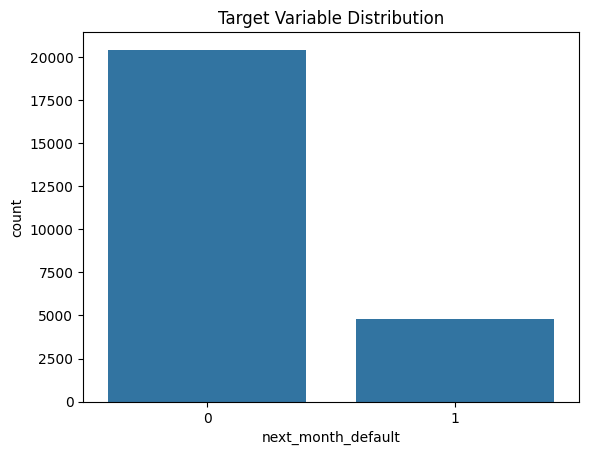

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='next_month_default', data=df)
plt.title("Target Variable Distribution")
plt.show()


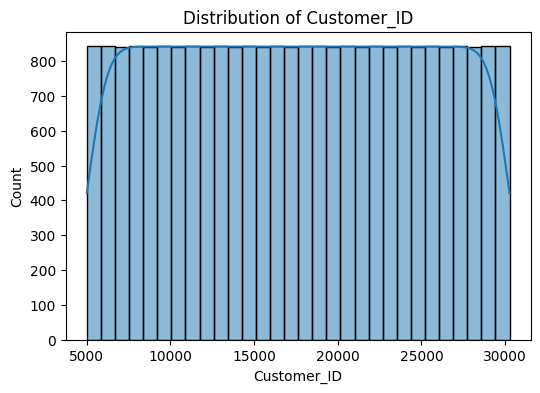

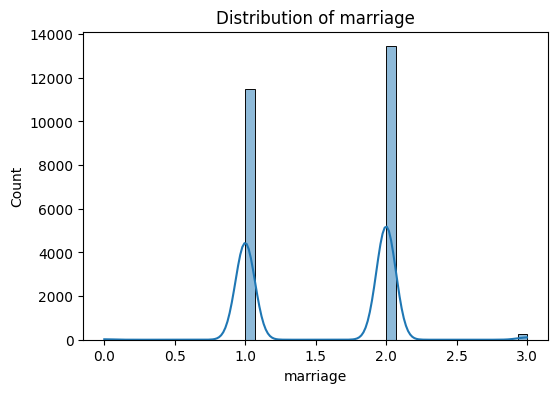

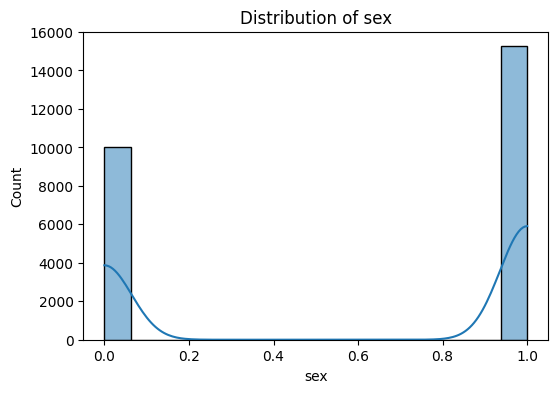

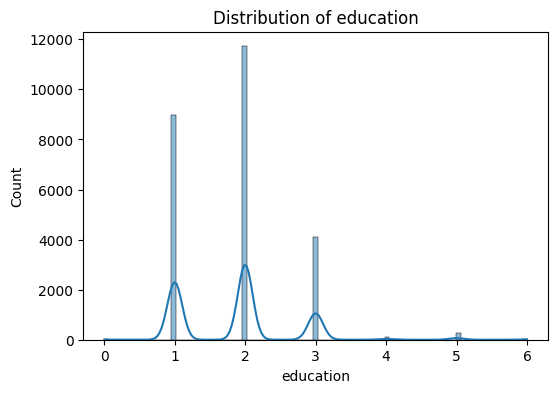

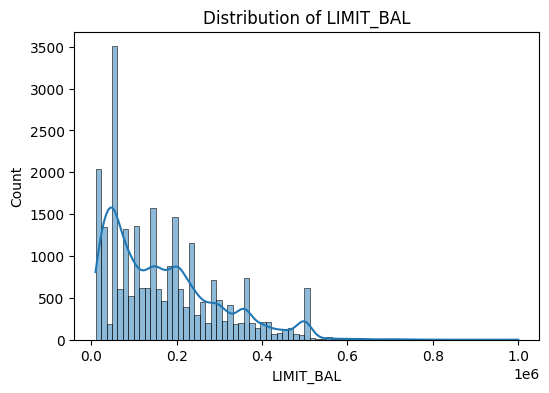

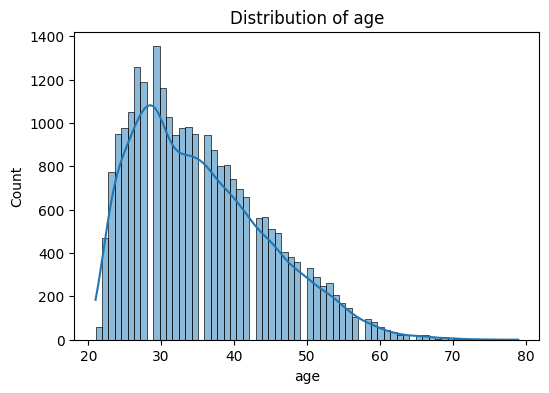

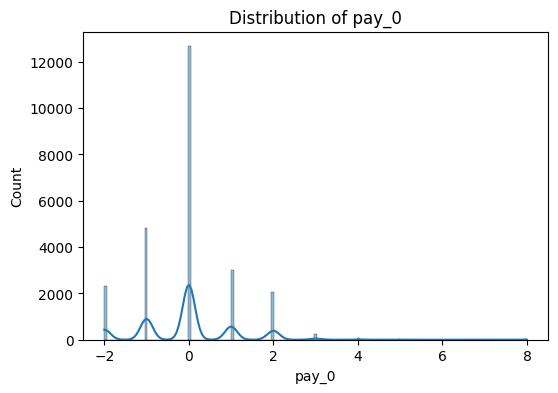

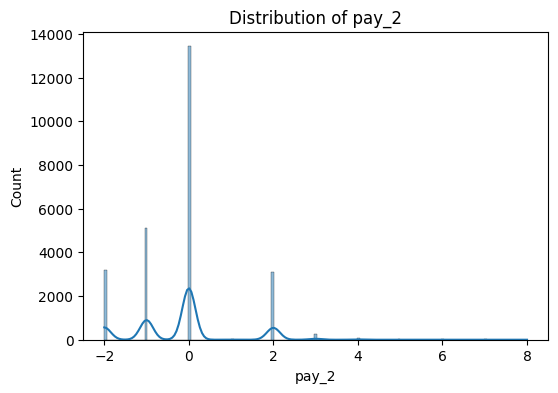

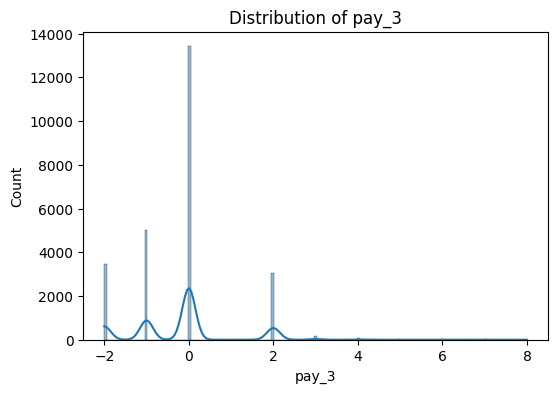

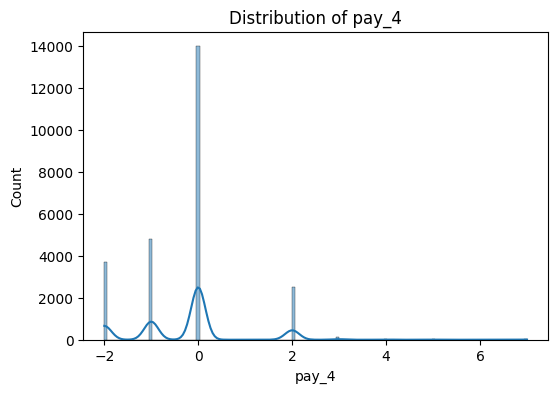

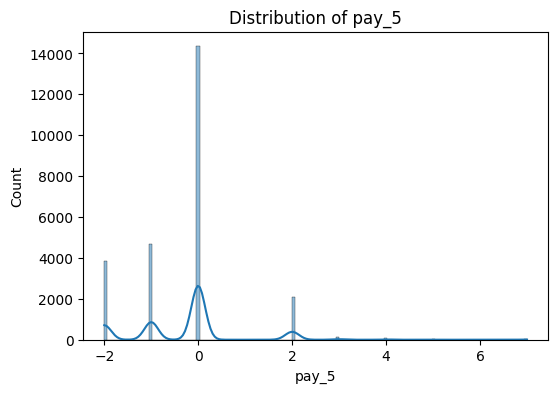

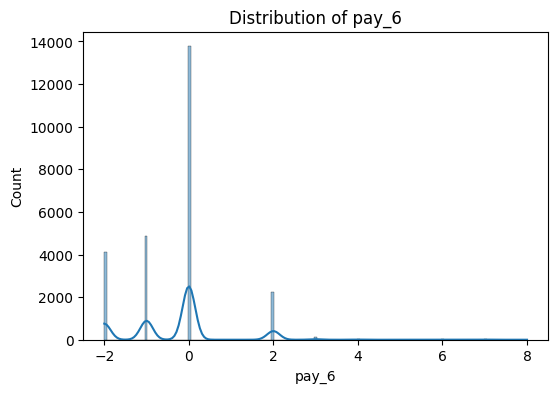

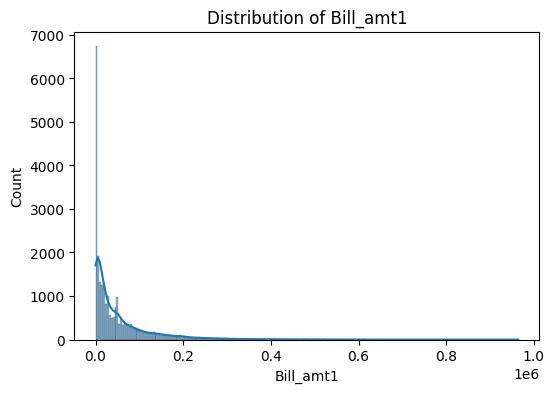

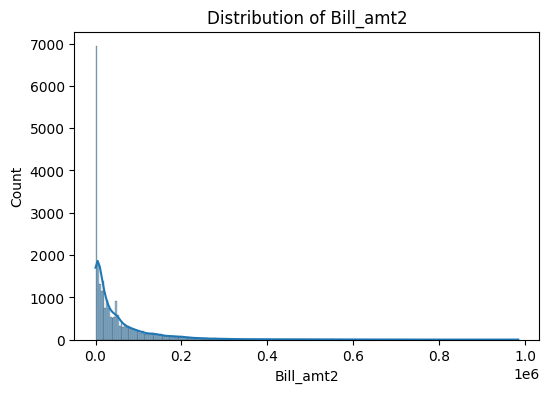

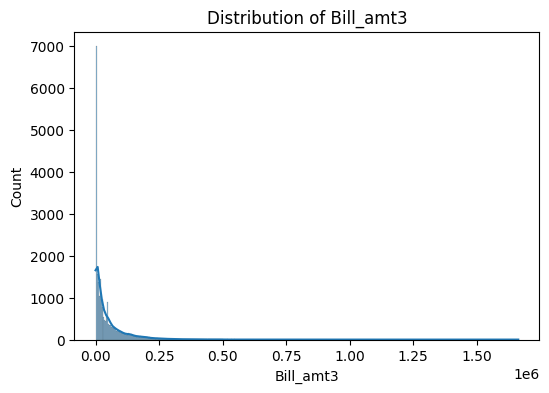

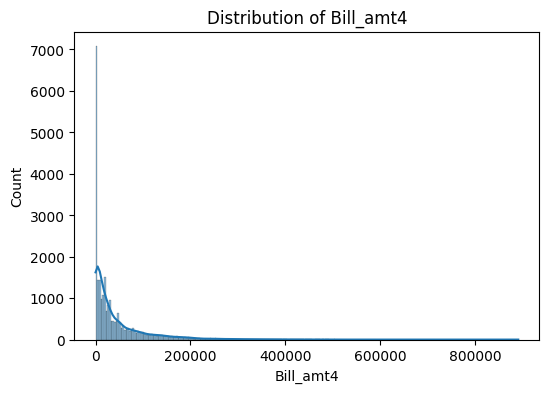

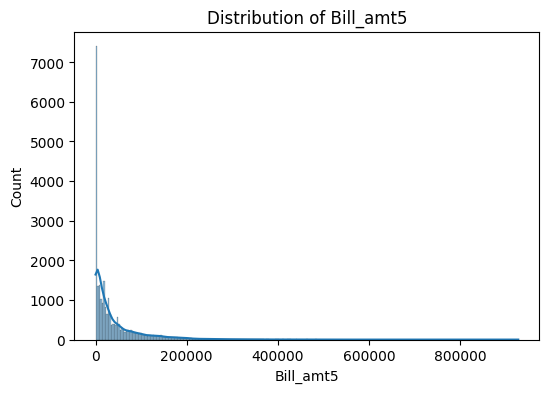

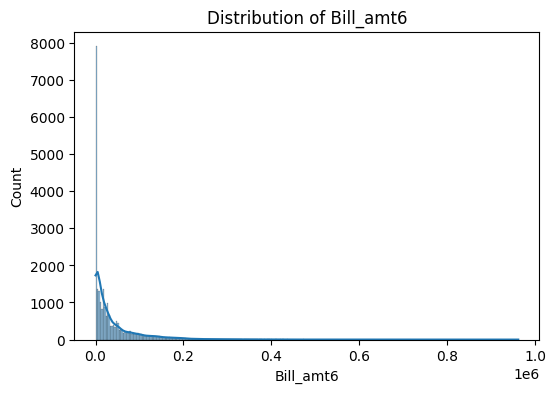

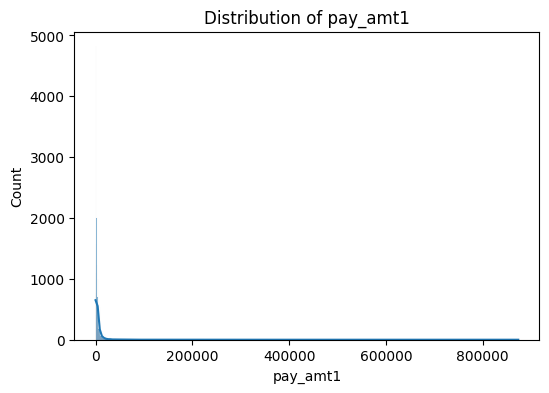

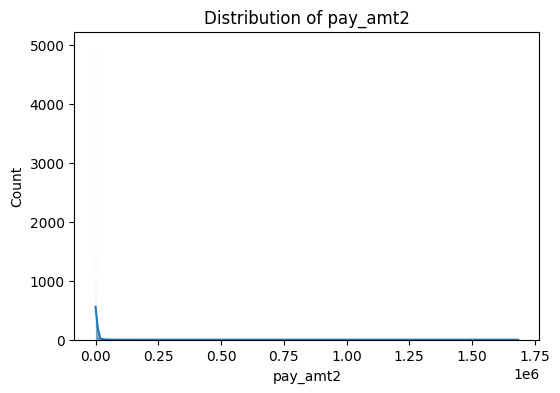

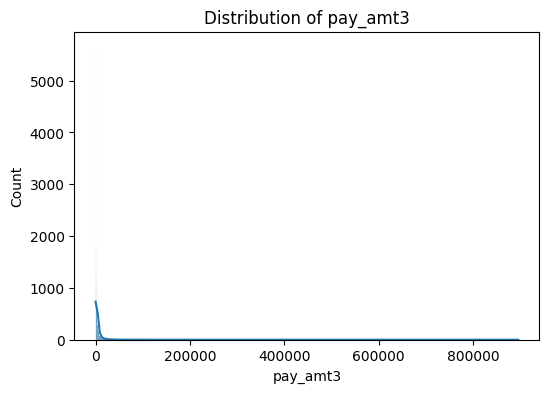

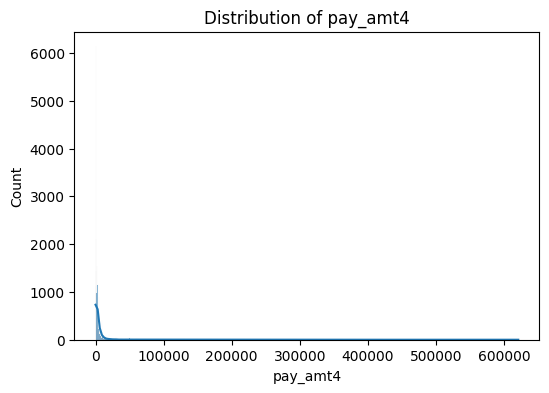

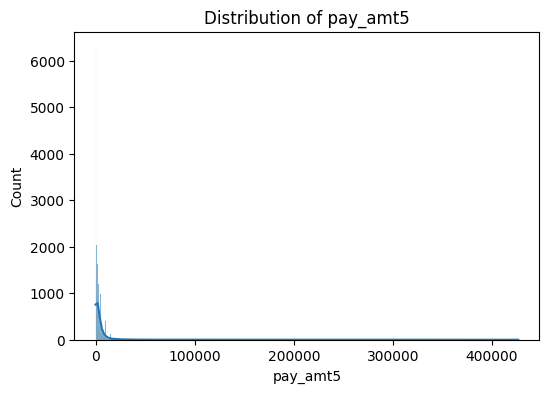

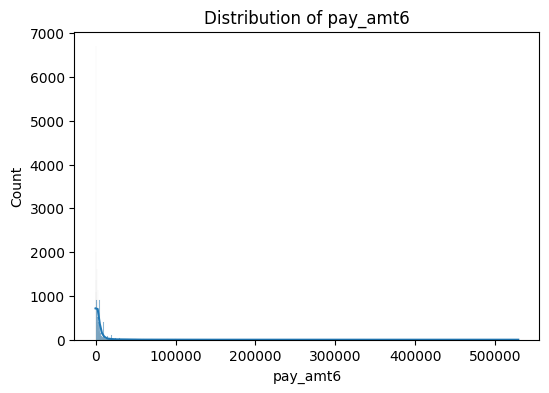

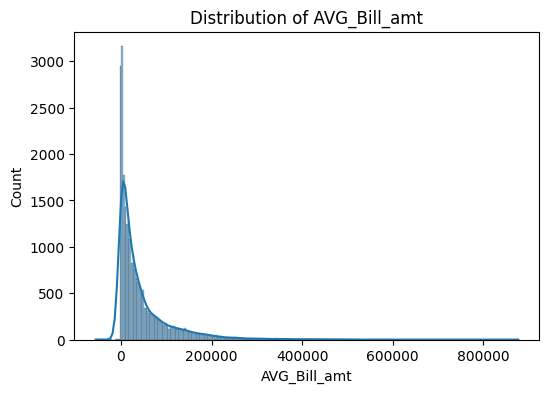

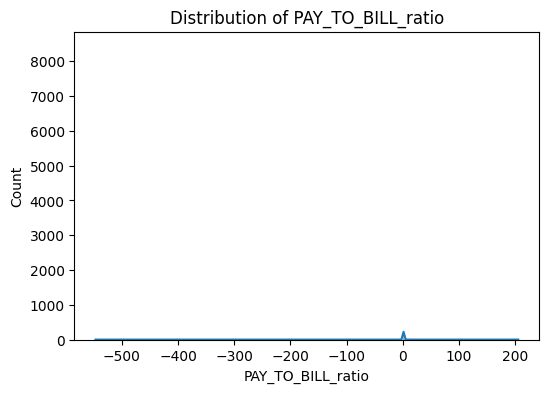

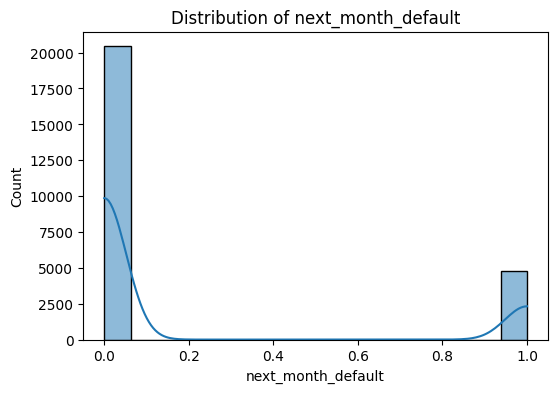

In [4]:
columns = df.select_dtypes(include=['int64','float64']).columns
for col in columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


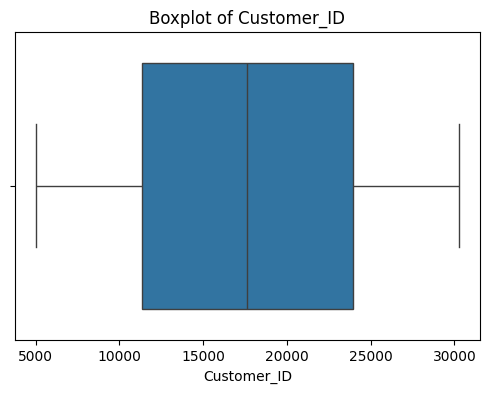

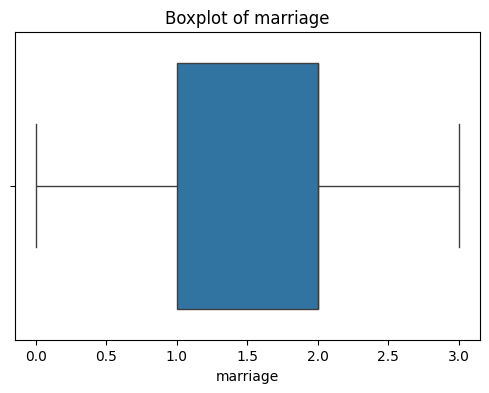

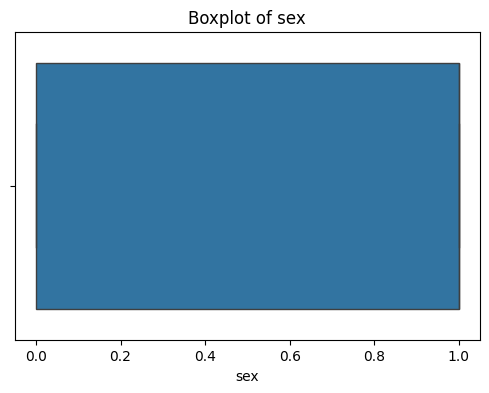

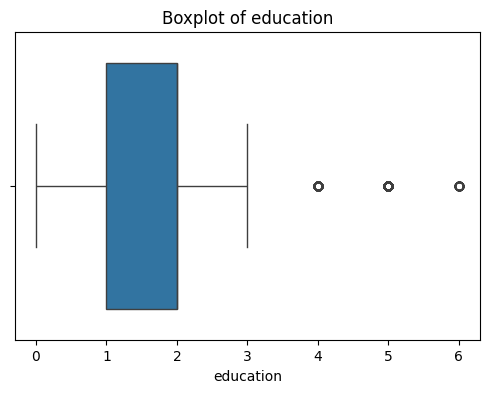

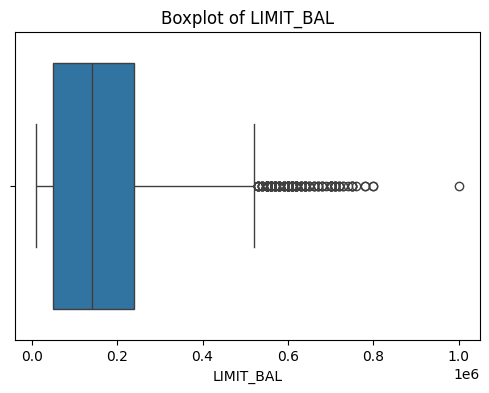

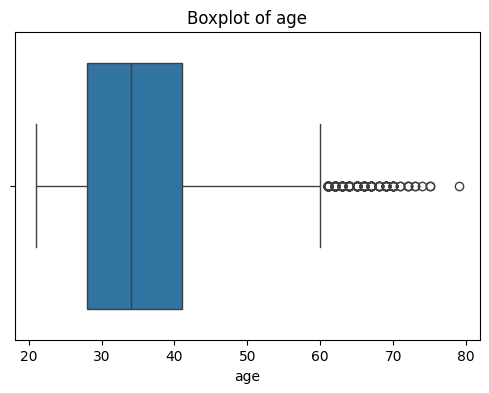

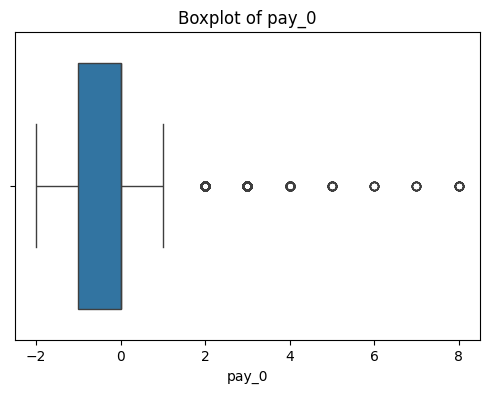

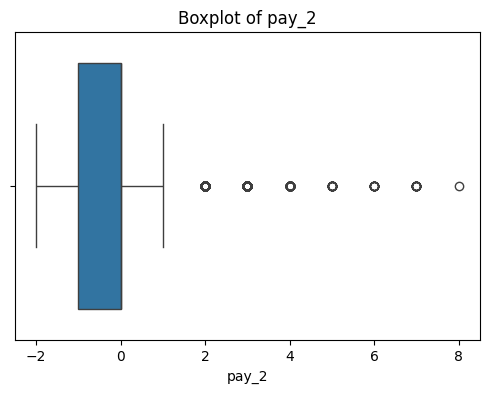

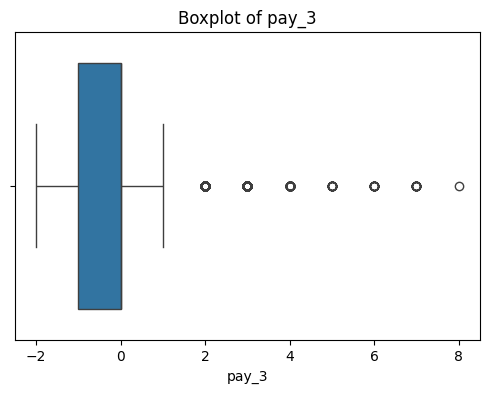

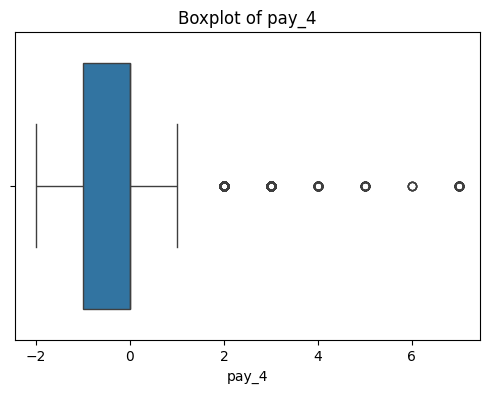

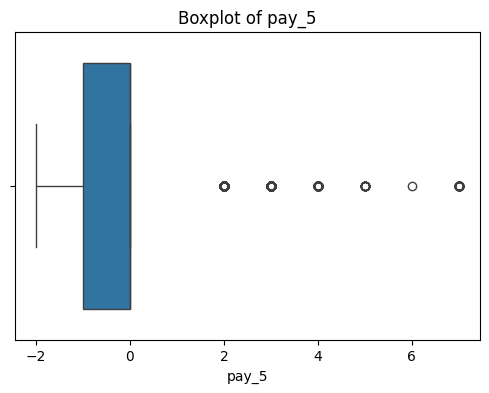

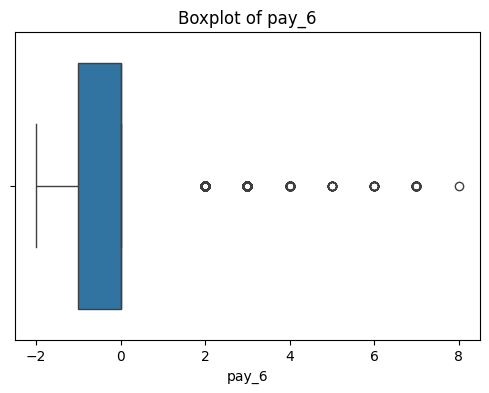

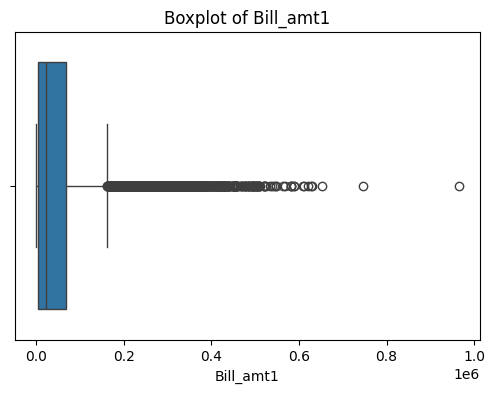

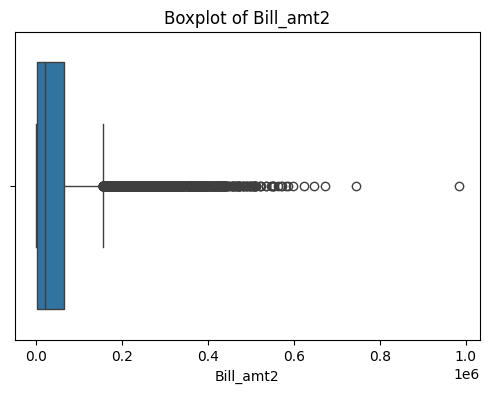

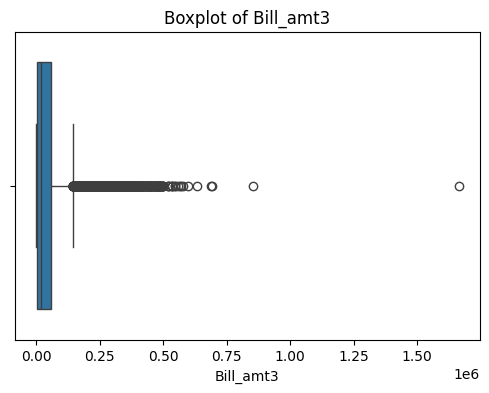

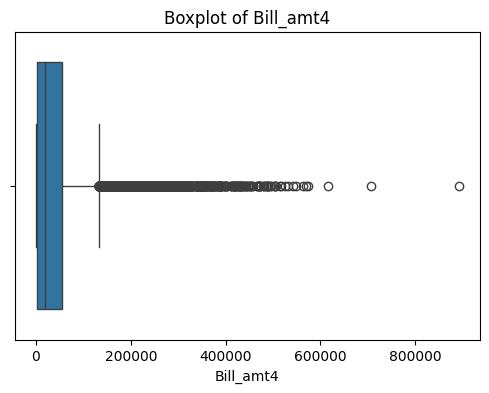

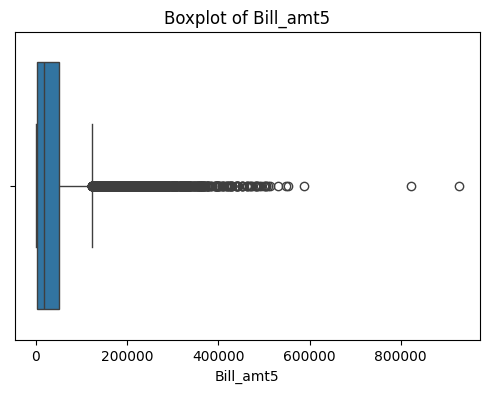

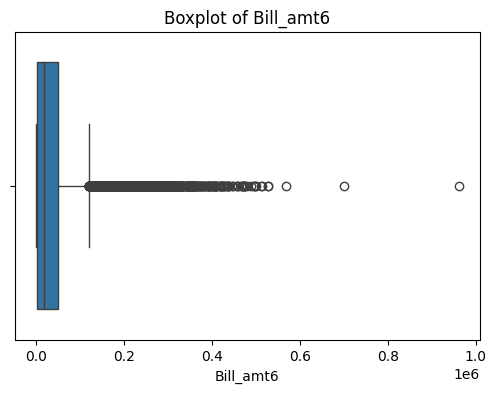

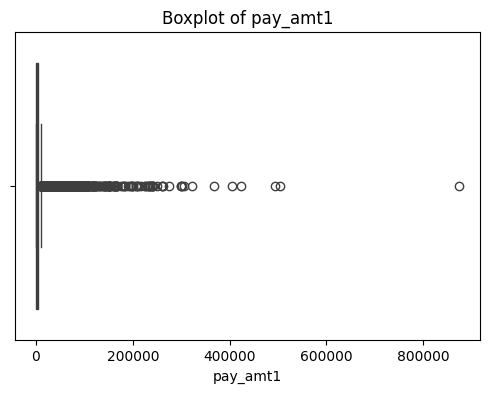

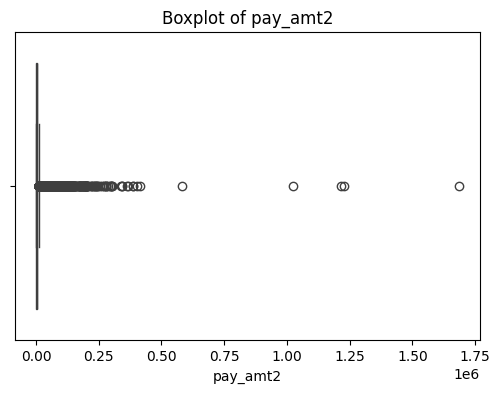

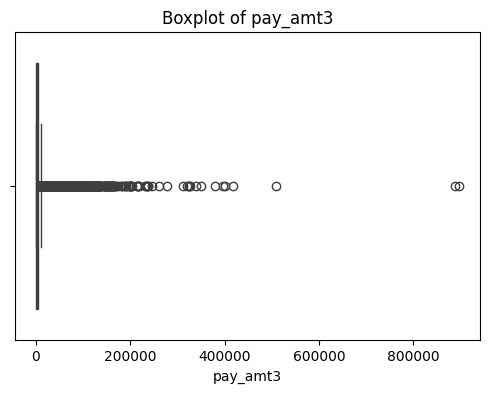

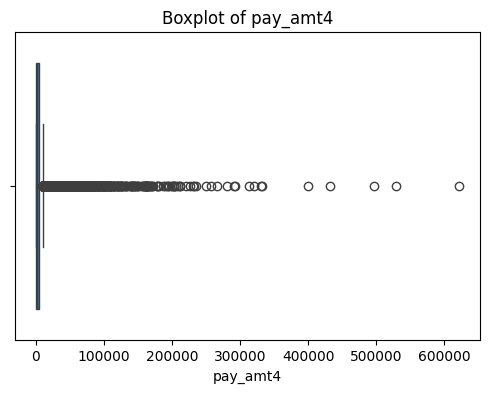

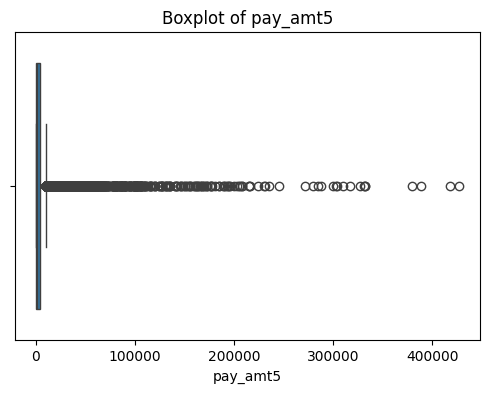

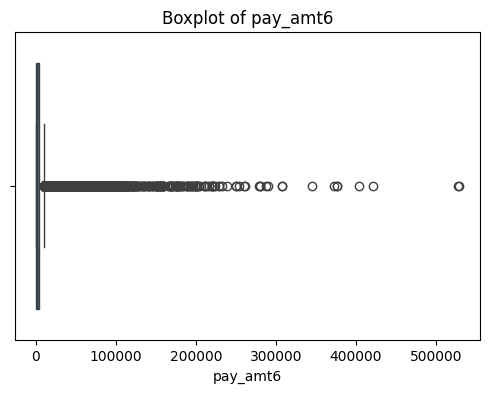

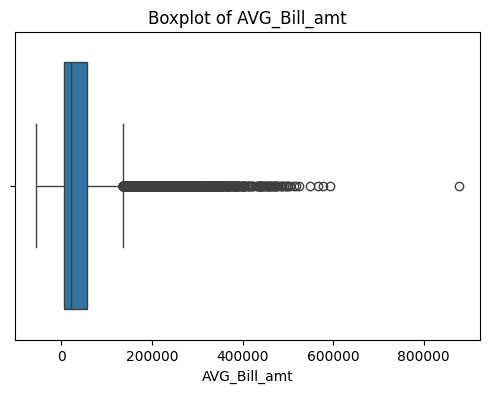

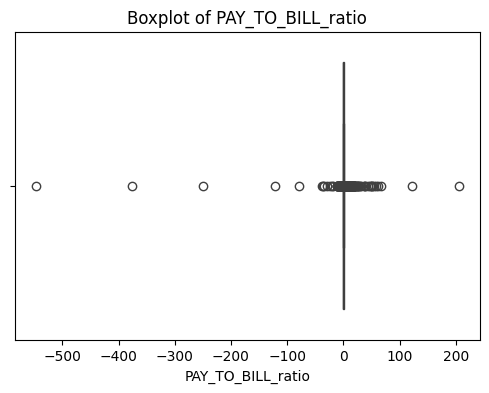

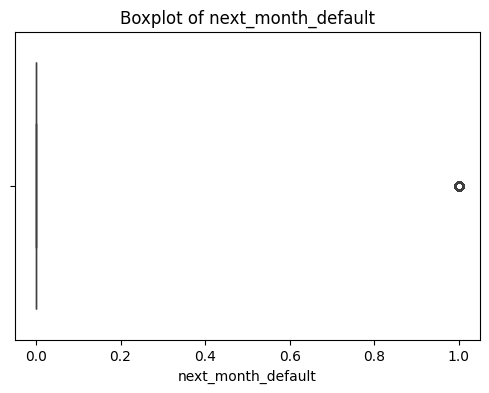

In [5]:
for col in columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

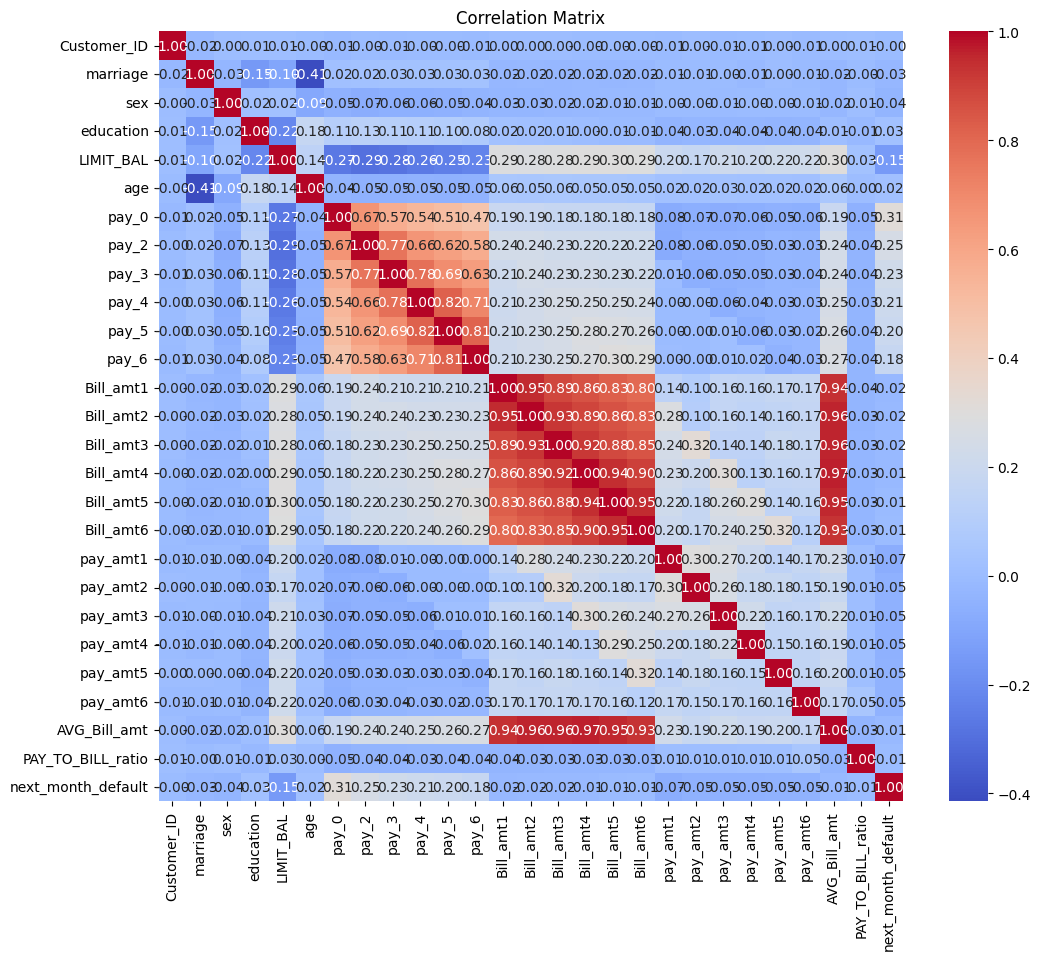

In [6]:
plt.figure(figsize=(12, 10))
corr = df[columns].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


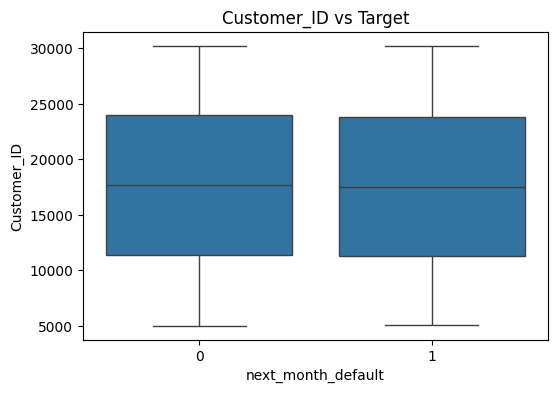

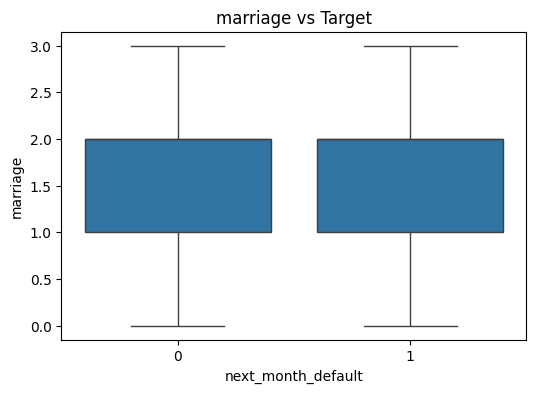

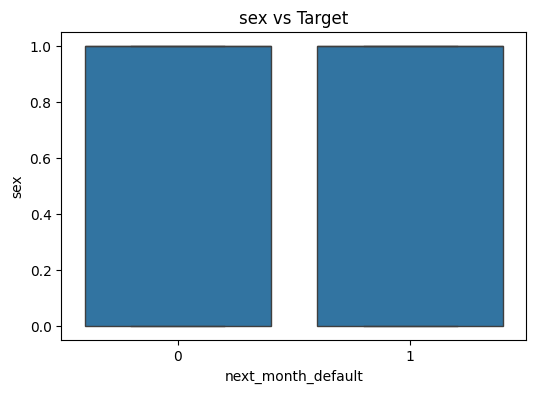

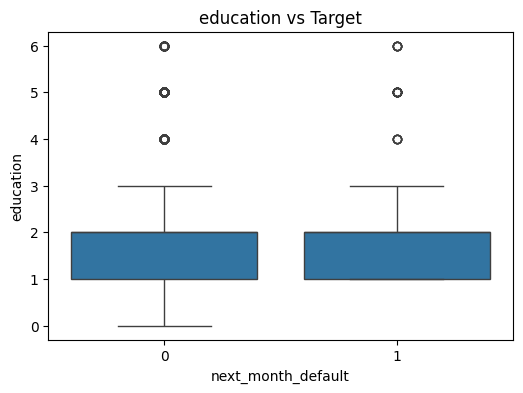

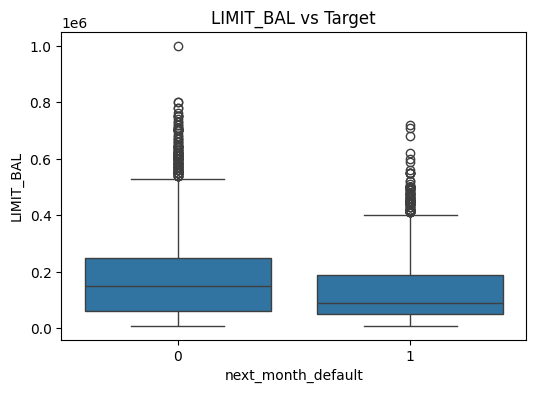

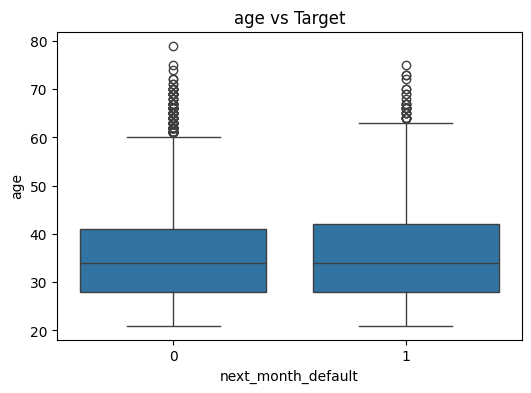

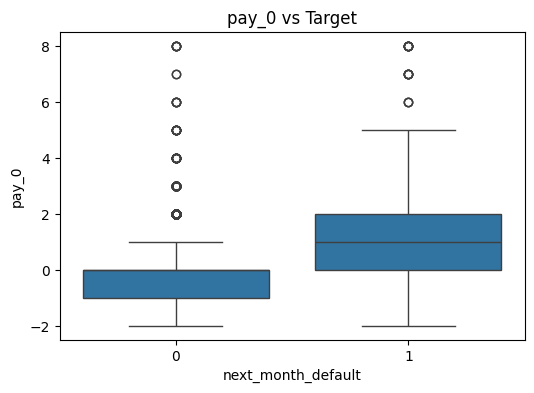

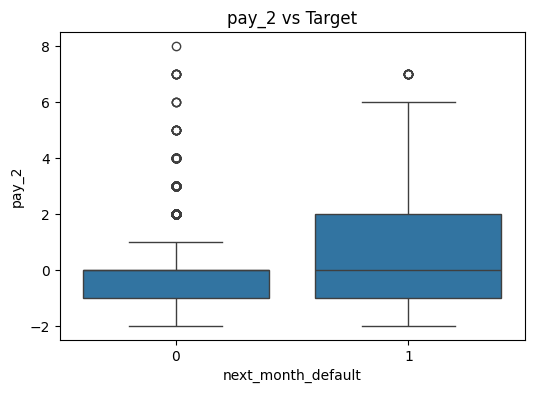

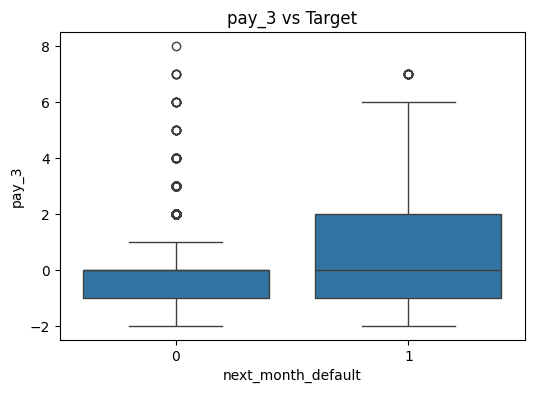

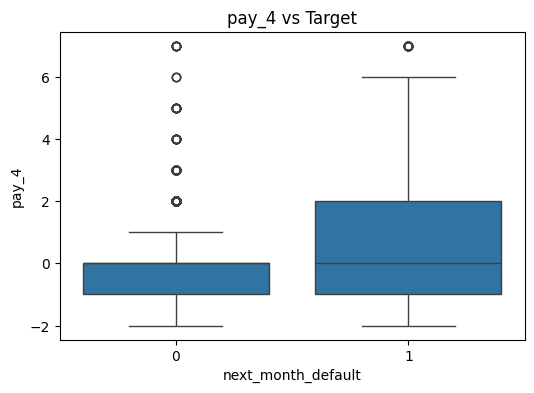

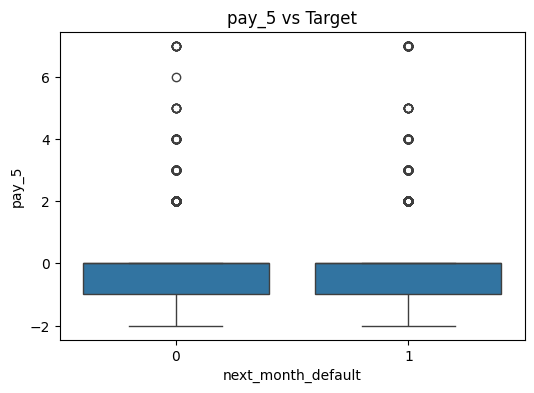

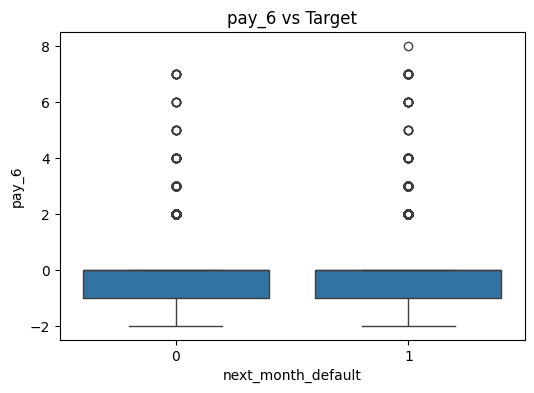

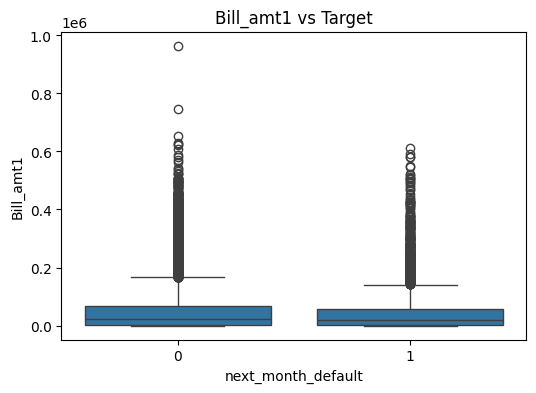

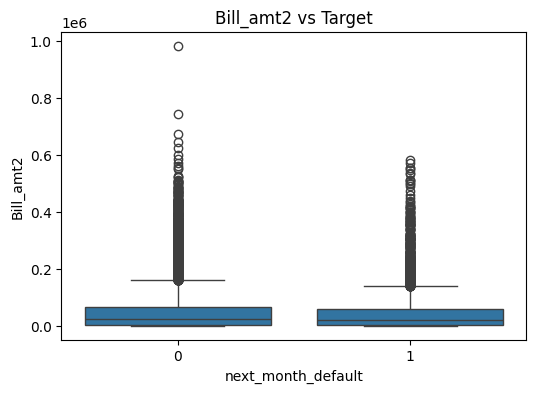

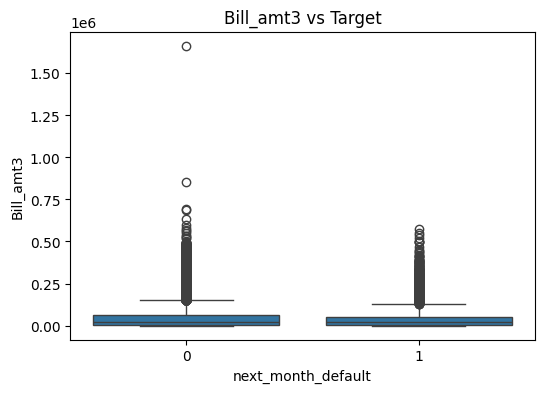

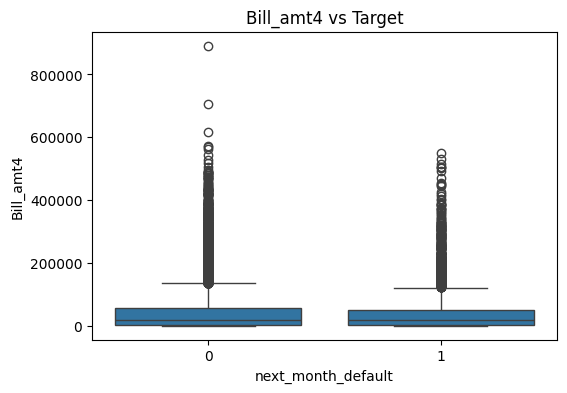

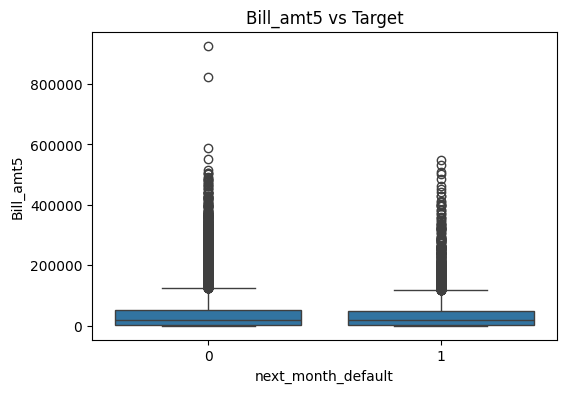

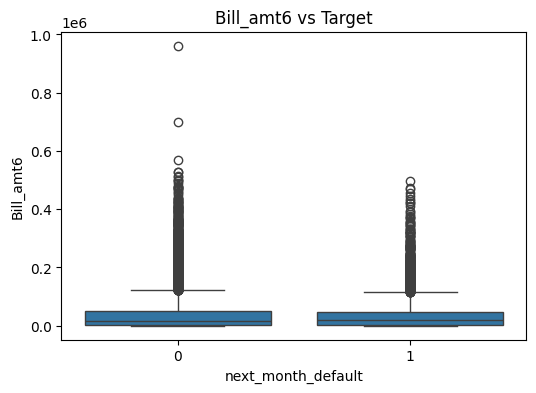

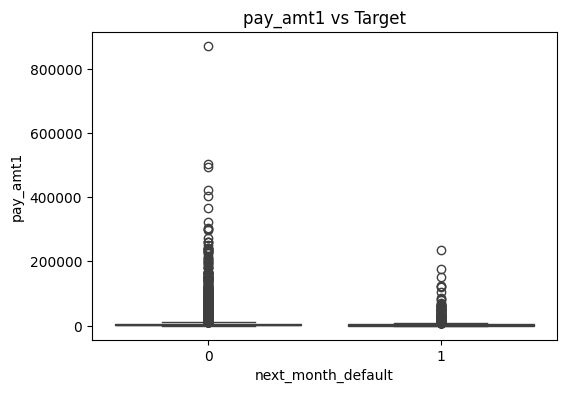

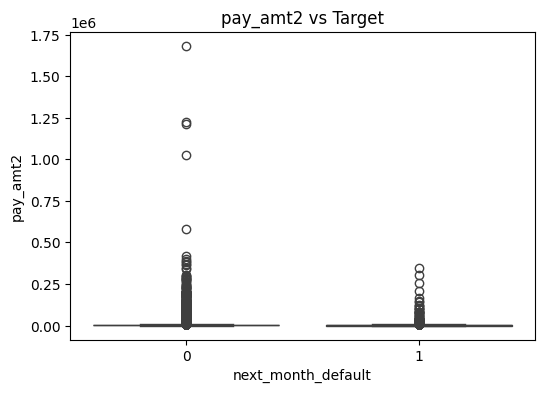

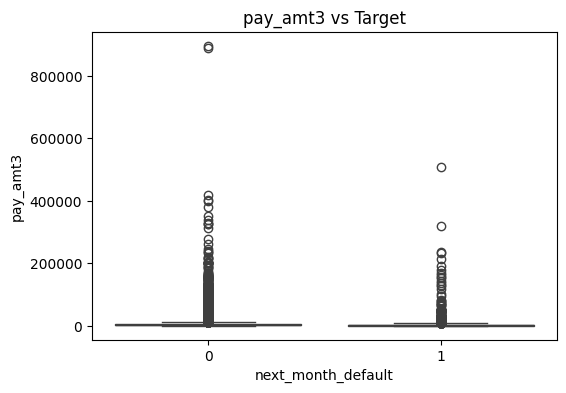

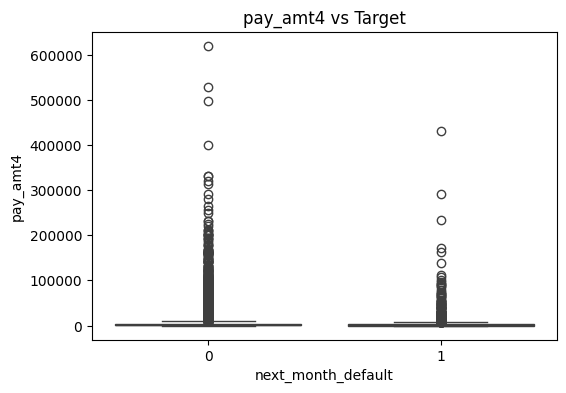

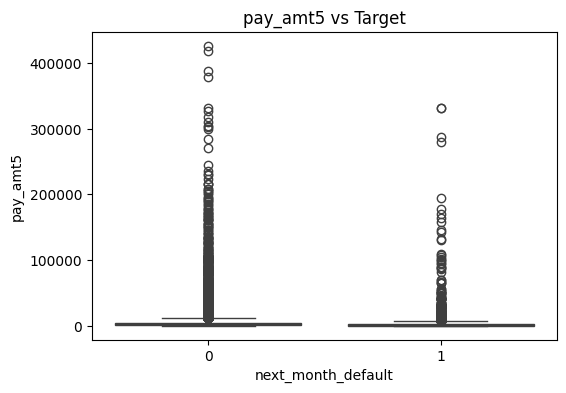

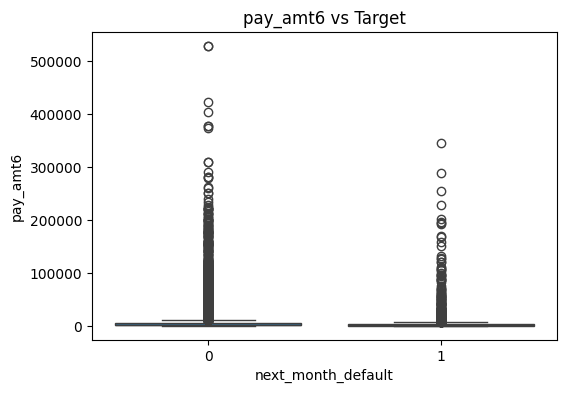

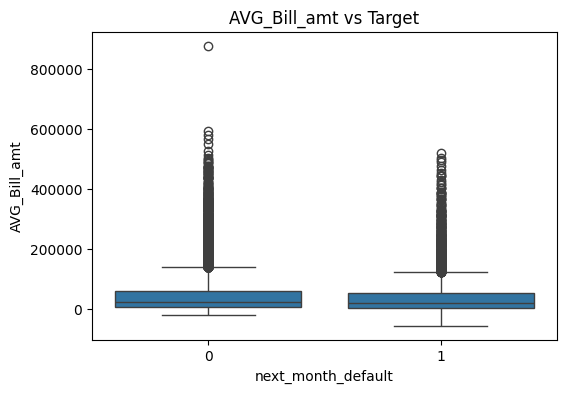

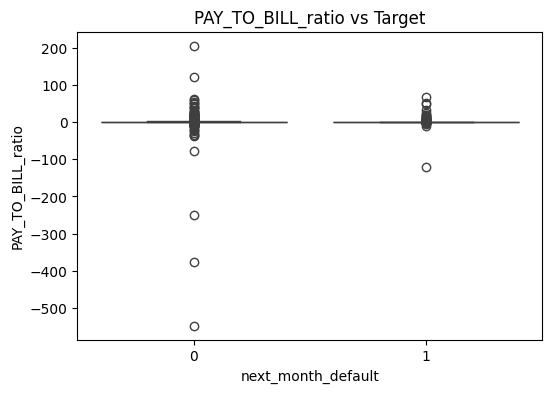

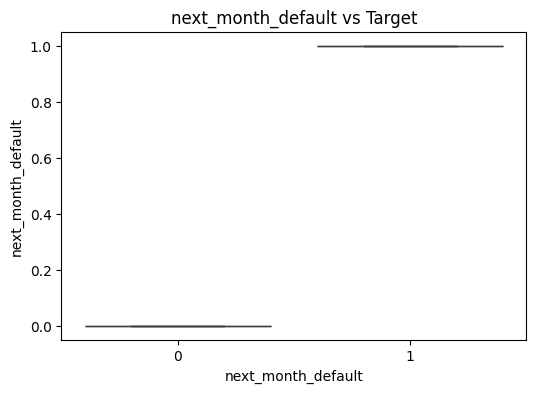

In [7]:
for col in columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='next_month_default', y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()

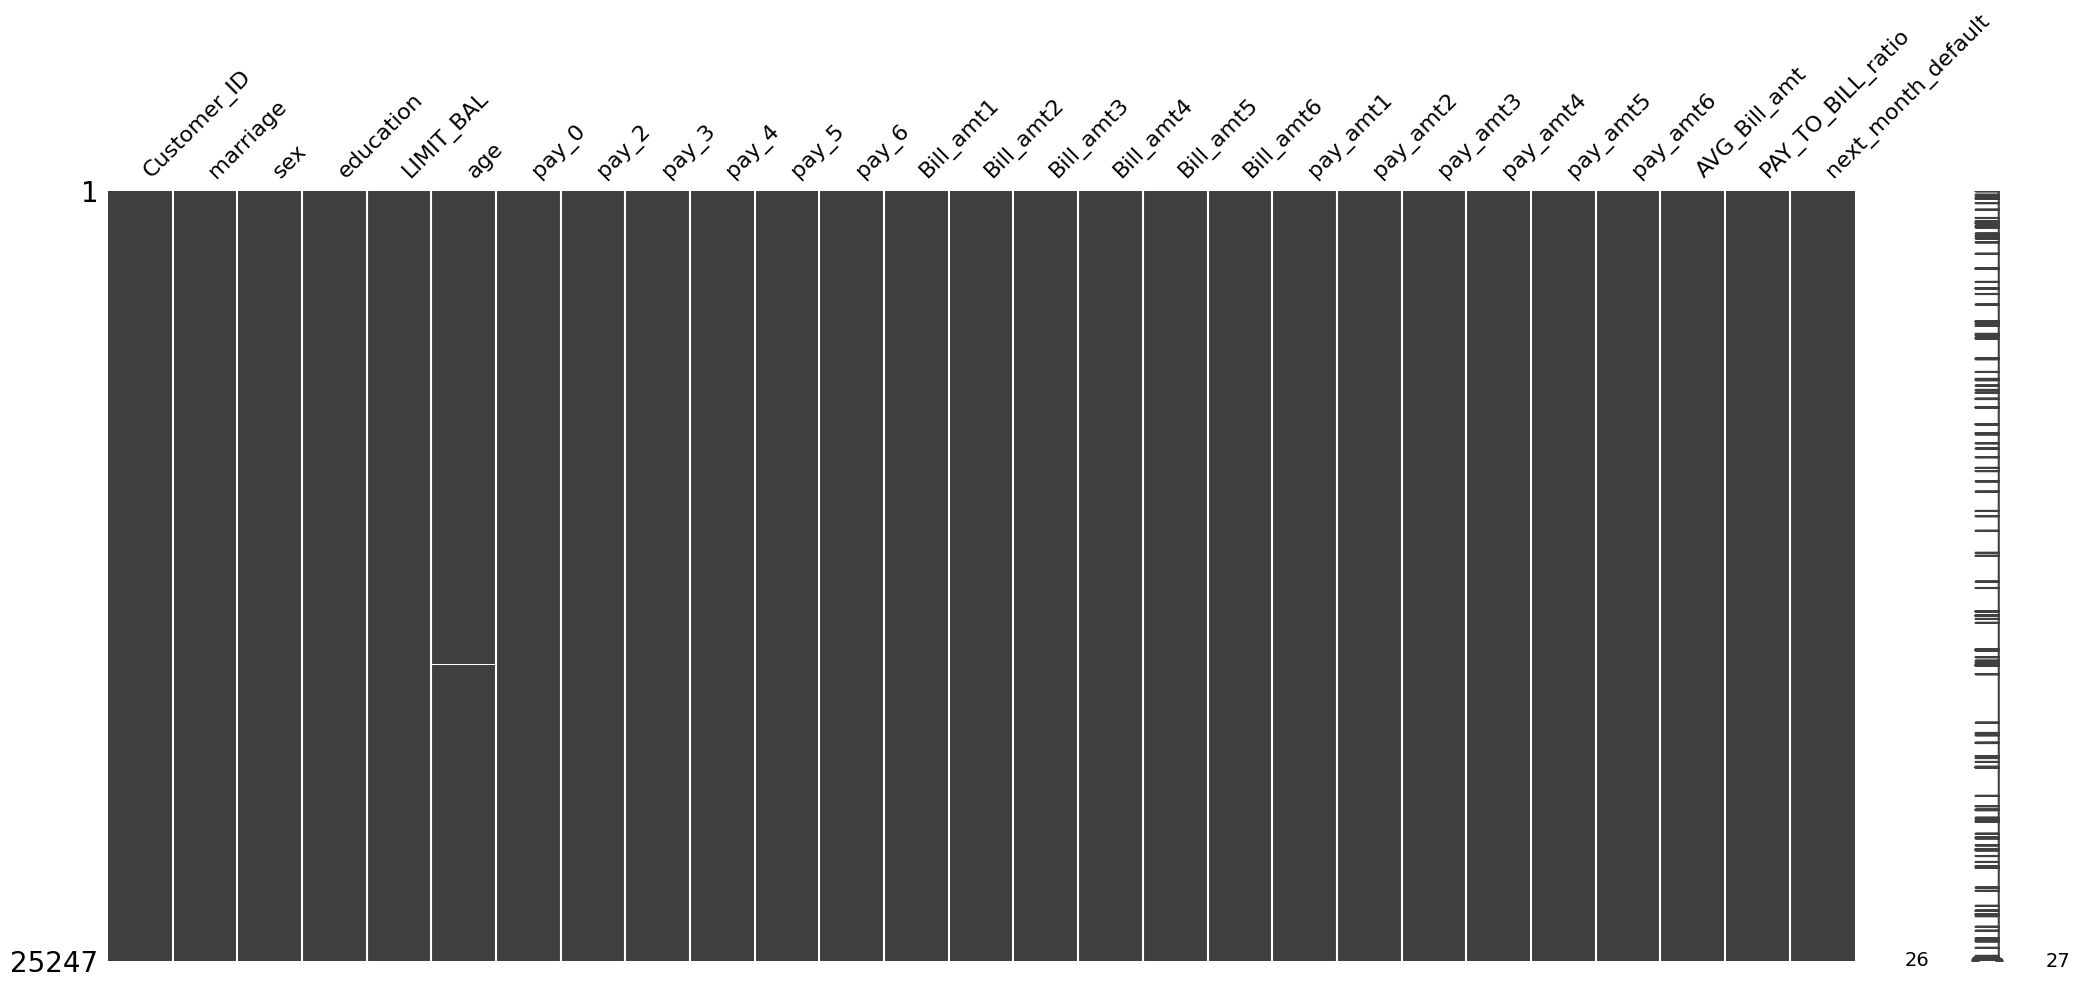

In [8]:
import missingno as msno
msno.matrix(df)
plt.show()

In [9]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="EDA Report")
profile.to_file("eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 27/27 [00:00<00:00, 347.50it/s]
C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\ydata_profiling\model\correlations.py:87: UserWarning: There was an attempt to calculate the auto correlation, but this failed.
To hide this warning, disable the calculation
(using `df.profile_report(correlations={"auto": {"calculate": False}})`
If this is problematic for your use case, please report this as an issue:
https://github.com/ydataai/ydata-profiling/issues
(include the error message: 'putmask: first argument must be an array')
  warnings.warn(


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
import sweetviz as sv

report = sv.analyze(df)
report.show_html("sweetviz_report.html")

                                             |                                             | [  0%]   00:00 ->…

Report sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("train_dataset_final1.csv")
df['age'].fillna(df['age'].median(), inplace=True)
df['education'] = df['education'].replace([0, 5, 6], 4)
df['marriage'] = df['marriage'].replace(0, 3)
print(df[['education', 'marriage']].value_counts())


education  marriage
2          2           5864
1          2           5805
2          1           5715
1          1           3135
3          1           2415
           2           1568
4          1            215
           2            204
2          3            138
3          3            132
1          3             48
4          3              8
Name: count, dtype: int64


In [12]:
from sklearn.preprocessing import LabelEncoder
for col in ['sex', 'education', 'marriage']:
    df[col] = LabelEncoder().fit_transform(df[col])
print("Target distribution:")
print(df['next_month_default'].value_counts(normalize=True))
print("\nTop correlations with target:")
print(df.corr()['next_month_default'].sort_values(ascending=False))


Target distribution:
next_month_default
0    0.809601
1    0.190399
Name: proportion, dtype: float64

Top correlations with target:
next_month_default    1.000000
pay_0                 0.312943
pay_2                 0.252125
pay_3                 0.226015
pay_4                 0.207488
pay_5                 0.196329
pay_6                 0.180387
education             0.032346
age                   0.017703
Customer_ID          -0.001893
PAY_TO_BILL_ratio    -0.005528
Bill_amt6            -0.005725
Bill_amt5            -0.008983
Bill_amt4            -0.012032
AVG_Bill_amt         -0.014694
Bill_amt2            -0.016079
Bill_amt3            -0.016706
Bill_amt1            -0.021729
marriage             -0.029242
sex                  -0.037537
pay_amt5             -0.046960
pay_amt6             -0.047116
pay_amt3             -0.050925
pay_amt2             -0.053623
pay_amt4             -0.053624
pay_amt1             -0.068882
LIMIT_BAL            -0.146010
Name: next_month_default, dtype

In [13]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
df['max_delay'] = df[pay_cols].max(axis=1)
df['delay_streak'] = (df[pay_cols] > 0).sum(axis=1)
df['repayment_ratio'] = df[[f'pay_amt{i}' for i in range(1, 7)]].sum(axis=1) / \
                        (df[[f'Bill_amt{i}' for i in range(1, 7)]].sum(axis=1) + 1)
df['bill_growth'] = df['Bill_amt1'] - df['Bill_amt6']
df['bill_avg'] = df[[f'Bill_amt{i}' for i in range(1, 7)]].mean(axis=1)
df['pay_amt_avg'] = df[[f'pay_amt{i}' for i in range(1, 7)]].mean(axis=1)
print(df[['max_delay', 'delay_streak', 'repayment_ratio', 'bill_growth', 'bill_avg', 'pay_amt_avg']].corrwith(df['next_month_default']))


max_delay          0.315777
delay_streak       0.389616
repayment_ratio   -0.004145
bill_growth       -0.028501
bill_avg          -0.014674
pay_amt_avg       -0.092854
dtype: float64


In [14]:
print(df.columns)

Index(['Customer_ID', 'marriage', 'sex', 'education', 'LIMIT_BAL', 'age',
       'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'Bill_amt1',
       'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
       'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6',
       'AVG_Bill_amt', 'PAY_TO_BILL_ratio', 'next_month_default', 'max_delay',
       'delay_streak', 'repayment_ratio', 'bill_growth', 'bill_avg',
       'pay_amt_avg'],
      dtype='object')


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['next_month_default', 'Customer_ID'])
y = df['next_month_default']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME.R'),
    "SVC": SVC(class_weight='balanced', probability=True),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}



In [17]:
from sklearn.metrics import f1_score

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    results[name] = f1
    print(f"{name}: F1 Score = {f1:.4f}")

best_model_name = max(results, key=results.get)
print(f"\n Best Model Based on F1 Score: {best_model_name} ({results[best_model_name]:.4f})")


Logistic Regression: F1 Score = 0.4959
Random Forest: F1 Score = 0.4110
Gradient Boosting: F1 Score = 0.4600


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost: F1 Score = 0.4555
SVC: F1 Score = 0.5042
Naive Bayes: F1 Score = 0.3679


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 966, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\subp

KNN: F1 Score = 0.4070


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [02:58:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost: F1 Score = 0.4225
[LightGBM] [Info] Number of positive: 3845, number of negative: 16352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002034 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4812
[LightGBM] [Info] Number of data points in the train set: 20197, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.190375 -> initscore=-1.447577
[LightGBM] [Info] Start training from score -1.447577
LightGBM: F1 Score = 0.4473

 Best Model Based on F1 Score: SVC (0.5042)


In [18]:
df['late_pay_ratio'] = df['delay_streak'] / 6
df['utilization'] = df['bill_avg'] / (df['LIMIT_BAL'] + 1)
df['debt_growth_rate'] = df['bill_growth'] / (df['LIMIT_BAL'] + 1)

In [19]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train_scaled, y_train)


In [20]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]


In [21]:
from sklearn.metrics import precision_recall_curve
import numpy as np

probs = best_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8) 
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Best threshold for F1 score: {best_thresh:.3f}")
print(f"Best F1 score: {np.max(f1_scores):.4f}")


Best threshold for F1 score: 0.328
Best F1 score: 0.5237


In [22]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)
best_model.fit(X_train_bal, y_train_bal)

probs = best_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_thresh = thresholds[np.argmax(f1_scores)]
print(f"New Best F1 Threshold: {best_thresh:.3f}")
print(f"New Best F1 Score: {np.max(f1_scores):.4f}")


New Best F1 Threshold: 0.674
New Best F1 Score: 0.5199


In [23]:
df['has_late_payment'] = (df[['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']] > 0).any(axis=1).astype(int)
df['all_months_paid'] = (df[['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']] <= 0).all(axis=1).astype(int)

df['bill_amt_std'] = df[[f'Bill_amt{i}' for i in range(1, 7)]].std(axis=1)
df['pay_amt_std'] = df[[f'pay_amt{i}' for i in range(1, 7)]].std(axis=1)

df['utilization_std'] = df['bill_amt_std'] / (df['LIMIT_BAL'] + 1)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME.R'),
    "SVC": SVC(class_weight='balanced', probability=True),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier()
}


In [25]:
from sklearn.metrics import f1_score

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    f1 = f1_score(y_test, y_pred)
    results[name] = f1
    print(f"{name}: F1 Score = {f1:.4f}")

best_model_name = max(results, key=results.get)
print(f"\n🔍 Best Model Based on F1 Score: {best_model_name} ({results[best_model_name]:.4f})")


Logistic Regression: F1 Score = 0.4959
Random Forest: F1 Score = 0.3968
Gradient Boosting: F1 Score = 0.4603


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


AdaBoost: F1 Score = 0.4555
SVC: F1 Score = 0.5042
Naive Bayes: F1 Score = 0.3679
KNN: F1 Score = 0.4070
XGBoost: F1 Score = 0.4225


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:05:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 3845, number of negative: 16352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001768 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4812
[LightGBM] [Info] Number of data points in the train set: 20197, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.190375 -> initscore=-1.447577
[LightGBM] [Info] Start training from score -1.447577
LightGBM: F1 Score = 0.4473

🔍 Best Model Based on F1 Score: SVC (0.5042)


In [26]:
drop_cols = [f'Bill_amt{i}' for i in range(1, 7)] + \
            [f'pay_amt{i}' for i in range(1, 7)] + \
            ['AVG_Bill_amt', 'PAY_TO_BILL_ratio']

df_cleaned = df.drop(columns=drop_cols)

df_cleaned['late_ratio'] = df_cleaned['delay_streak'] / 6
df_cleaned['high_utilization_flag'] = (df_cleaned['bill_avg'] > 0.8 * df_cleaned['LIMIT_BAL']).astype(int)
df_cleaned['payment_consistency'] = (df_cleaned['pay_amt_avg'] > 0) & \
                                     (df_cleaned['pay_amt_std'] < 0.1 * (df_cleaned['pay_amt_avg'] + 1))
df_cleaned['payment_consistency'] = df_cleaned['payment_consistency'].astype(int)

X = df_cleaned.drop(columns=['Customer_ID', 'next_month_default'])
y = df_cleaned['next_month_default']


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [28]:
from xgboost import XGBClassifier
scale_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_ratio,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:05:12] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [29]:
from sklearn.metrics import precision_recall_curve, f1_score
import numpy as np

probs = xgb_model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_thresh = thresholds[np.argmax(f1_scores)]
best_f1 = np.max(f1_scores)

print(f"Best Threshold: {best_thresh:.3f}")
print(f"Best F1 Score: {best_f1:.4f}")


Best Threshold: 0.580
Best F1 Score: 0.4933


 Classification Report:
              precision    recall  f1-score   support

           0     0.8811    0.8789    0.8800      4088
           1     0.4907    0.4958    0.4933       962

    accuracy                         0.8059      5050
   macro avg     0.6859    0.6874    0.6866      5050
weighted avg     0.8067    0.8059    0.8063      5050



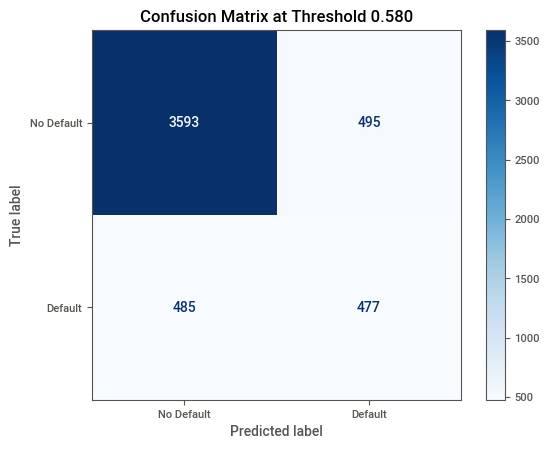

In [30]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

final_preds = (probs >= best_thresh).astype(int)

print(" Classification Report:")
print(classification_report(y_test, final_preds, digits=4))
cm = confusion_matrix(y_test, final_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Default", "Default"])
disp.plot(cmap="Blues", values_format="d")
plt.title(f"Confusion Matrix at Threshold {best_thresh:.3f}")
plt.show()


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

scale_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME.R'),
    "SVC": SVC(class_weight='balanced', probability=True),
    "Naive Bayes": GaussianNB(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_ratio),
    "LightGBM": LGBMClassifier(scale_pos_weight=scale_ratio)
}

for model in models.values():
    model.fit(X_train_scaled, y_train)


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:06:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 3845, number of negative: 16352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001120 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2545
[LightGBM] [Info] Number of data points in the train set: 20197, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.190375 -> initscore=-1.447577
[LightGBM] [Info] Start training from score -1.447577


In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, fbeta_score, roc_auc_score
import pandas as pd

metrics_summary = {}

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = model.decision_function(X_test_scaled)

    preds = model.predict(X_test_scaled)
    
    metrics_summary[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F2 Score": fbeta_score(y_test, preds, beta=2),
        "ROC-AUC": roc_auc_score(y_test, probs)
    }

metrics_df = pd.DataFrame(metrics_summary).T
metrics_df = metrics_df.sort_values("F2 Score", ascending=False)
metrics_df.round(4)


FloatingPointError: underflow encountered in exp

In [33]:
from sklearn.metrics import precision_recall_curve, fbeta_score
import pandas as pd

def find_best_threshold_f2(model, X, y_true, beta=2):
    probs = model.predict_proba(X)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_true, probs)
    f2_scores = (1 + beta**2) * (precision * recall) / (beta**2 * precision + recall + 1e-8)
    best_idx = f2_scores.argmax()
    return {
        "Threshold": thresholds[best_idx],
        "F2 Score": f2_scores[best_idx],
        "Precision": precision[best_idx],
        "Recall": recall[best_idx]
    }

f2_results = {}

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        try:
            result = find_best_threshold_f2(model, X_test_scaled, y_test, beta=2)
            f2_results[name] = result
        except Exception as e:
            print(f"{name}: Failed with error: {e}")
    else:
        print(f"{name}: Skipped (no predict_proba method)")

f2_df = pd.DataFrame(f2_results).T
f2_df = f2_df.sort_values("F2 Score", ascending=False)
print("\nTuned F2 Score Summary:")
print(f2_df.round(4))


Naive Bayes: Failed with error: underflow encountered in exp

Tuned F2 Score Summary:
                     Threshold  F2 Score  Precision  Recall
AdaBoost                0.4902    0.6152     0.3336  0.7796
Gradient Boosting       0.1211    0.6127     0.3169  0.7994
LightGBM                0.2881    0.6104     0.2835  0.8576
SVC                     0.0924    0.6076     0.2690  0.8867
Random Forest           0.1300    0.6043     0.3076  0.7963
XGBoost                 0.2415    0.5996     0.2970  0.8046
Logistic Regression     0.3930    0.5935     0.3372  0.7328
KNN                     0.2000    0.5675     0.2808  0.7620


In [34]:

drop_cols = [f'Bill_amt{i}' for i in range(1, 7)] + [f'pay_amt{i}' for i in range(1, 7)]
df_cleaned = df.drop(columns=drop_cols)

pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
df_cleaned['late_count'] = (df[pay_cols] > 0).sum(axis=1)

df_cleaned['max_delay'] = df[pay_cols].max(axis=1)

available_pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
df_cleaned['pay_var'] = df[available_pay_cols].std(axis=1)



In [35]:
df_cleaned['bill_avg'] = df[[f'Bill_amt{i}' for i in range(1, 7)]].mean(axis=1)
df_cleaned['pay_avg'] = df[[f'pay_amt{i}' for i in range(1, 7)]].mean(axis=1)

df_cleaned['repayment_ratio'] = df_cleaned['pay_avg'] / (df_cleaned['bill_avg'] + 1)

df_cleaned['utilization_ratio'] = df_cleaned['bill_avg'] / (df_cleaned['LIMIT_BAL'] + 1)
df_cleaned['pay_to_limit'] = df_cleaned['pay_avg'] / (df_cleaned['LIMIT_BAL'] + 1)


In [36]:
df_cleaned['bill_growth'] = df['Bill_amt1'] - df['Bill_amt6']

df_cleaned['pay_vs_bill_1'] = df['pay_amt1'] - df['Bill_amt1']
df_cleaned['has_delinquency'] = (df_cleaned['late_count'] > 0).astype(int)
df_cleaned['high_utilization_flag'] = (df_cleaned['utilization_ratio'] > 0.9).astype(int)



In [37]:
X = df_cleaned.drop(columns=['Customer_ID', 'next_month_default'])
y = df_cleaned['next_month_default']


In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [39]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import precision_recall_curve, fbeta_score

scale_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME.R'),
    "LightGBM": LGBMClassifier(scale_pos_weight=scale_ratio, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', 
                             scale_pos_weight=scale_ratio, random_state=42)
}

def find_best_thresh_f2(m, X, y, beta=2):
    probs = m.predict_proba(X)[:, 1]
    p, r, thresholds = precision_recall_curve(y, probs)
    f2 = (1 + beta**2) * (p * r) / (beta**2 * p + r + 1e-8)
    idx = f2.argmax()
    return thresholds[idx], f2[idx]

f2_results = {}
for name, mdl in models.items():
    mdl.fit(X_train_scaled, y_train)
    thresh, best_f2 = find_best_thresh_f2(mdl, X_test_scaled, y_test, beta=2)
    f2_results[name] = {"Threshold": thresh, "F2 Score": best_f2}

import pandas as pd
f2_df = pd.DataFrame(f2_results).T.sort_values("F2 Score", ascending=False)
print("\nRefined Model F2 Results:")
print(f2_df.round(4))


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


[LightGBM] [Info] Number of positive: 3845, number of negative: 16352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001461 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4137
[LightGBM] [Info] Number of data points in the train set: 20197, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.190375 -> initscore=-1.447577
[LightGBM] [Info] Start training from score -1.447577

Refined Model F2 Results:
          Threshold  F2 Score
LightGBM     0.3521    0.6180
AdaBoost     0.4901    0.6132
XGBoost      0.2739    0.6028


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:07:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [40]:
from sklearn.metrics import classification_report

best_model_name = f2_df.index[0]
best_model = models[best_model_name]
best_thresh = f2_df.loc[best_model_name, "Threshold"]

probs = best_model.predict_proba(X_test_scaled)[:, 1]
preds = (probs >= best_thresh).astype(int)

print(f"Best Model: {best_model_name} (Threshold = {best_thresh:.3f})\n")
print(classification_report(y_test, preds, digits=4))


Best Model: LightGBM (Threshold = 0.352)

              precision    recall  f1-score   support

           0     0.9282    0.6040    0.7318      4088
           1     0.3226    0.8015    0.4600       962

    accuracy                         0.6416      5050
   macro avg     0.6254    0.7027    0.5959      5050
weighted avg     0.8128    0.6416    0.6800      5050



In [41]:

pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

df['late_1m'] = (df[pay_cols] == 1).sum(axis=1)
df['late_2m'] = (df[pay_cols] == 2).sum(axis=1)
df['late_over2m'] = (df[pay_cols] > 2).sum(axis=1)
df['revolving_months'] = (df[pay_cols] == 0).sum(axis=1)
df['fully_paid_months'] = (df[pay_cols] == -1).sum(axis=1)


In [42]:

df['bill_avg'] = df[[f'Bill_amt{i}' for i in range(1, 7)]].mean(axis=1)
df['utilization_ratio'] = df['bill_avg'] / (df['LIMIT_BAL'] + 1)
df['repayment_ratio'] = df['pay_amt_avg'] / (df['bill_avg'] + 1)
df['pay_to_limit'] = df['pay_amt_avg'] / (df['LIMIT_BAL'] + 1)


In [43]:
df['missed_last_month'] = (df['pay_0'] > 0).astype(int)
df['never_paid'] = (df[[f'pay_amt{i}' for i in range(1, 7)]].sum(axis=1) == 0).astype(int)
df['always_late'] = (df[pay_cols] > 0).all(axis=1).astype(int)
df['high_utilization_flag'] = (df['utilization_ratio'] > 0.9).astype(int)


In [44]:
df['risk_score'] = (
    1 * df['late_1m'] +
    2 * df['late_2m'] +
    3 * df['late_over2m'] +
    2 * df['always_late'] +
    2 * df['missed_last_month'] +
    1 * df['high_utilization_flag'] +
    1 * (1 - df['repayment_ratio'])
)


In [45]:
raw_pay_cols = [f'pay_amt{i}' for i in range(1, 7)]
raw_bill_cols = [f'Bill_amt{i}' for i in range(1, 7)]
drop_cols = raw_pay_cols + raw_bill_cols
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)
X = df.drop(columns=['Customer_ID', 'next_month_default'])
y = df['next_month_default']


In [46]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, fbeta_score, roc_auc_score,
    precision_recall_curve
)
import pandas as pd

scale_ratio = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "SVC": SVC(probability=True, class_weight='balanced'),
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "LightGBM": LGBMClassifier(scale_pos_weight=scale_ratio),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_ratio),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME.R'),
    "KNN": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(class_weight='balanced')
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = model.decision_function(X_test_scaled)

    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)
    best_idx = f2_scores.argmax()
    best_thresh = thresholds[best_idx]
    preds = (probs >= best_thresh).astype(int)

    results[name] = {
        "Threshold": best_thresh,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F2 Score": fbeta_score(y_test, preds, beta=2),
        "ROC-AUC": roc_auc_score(y_test, probs)
    }


metrics_df = pd.DataFrame(results).T.sort_values("F2 Score", ascending=False)
print(metrics_df.round(4))


[LightGBM] [Info] Number of positive: 3845, number of negative: 16352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3852
[LightGBM] [Info] Number of data points in the train set: 20197, number of used features: 38
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.190375 -> initscore=-1.447577
[LightGBM] [Info] Start training from score -1.447577


FloatingPointError: underflow encountered in exp

In [48]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, fbeta_score, roc_auc_score

base_estimators = [
    ('lgbm', LGBMClassifier(scale_pos_weight=scale_ratio, random_state=42)),
    ('svc', SVC(probability=True, class_weight='balanced')),
    ('ada', AdaBoostClassifier(algorithm='SAMME.R'))
]

stacked_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=5,
    n_jobs=-1
)

stacked_model.fit(X_train_scaled, y_train)

probs = stacked_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

final_preds = (probs >= best_thresh).astype(int)
from sklearn.metrics import classification_report
print(f" Stacked Model - Best Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")
print(classification_report(y_test, final_preds, digits=4))
print("ROC-AUC Score:", roc_auc_score(y_test, probs).round(4))


 Stacked Model - Best Threshold: 0.3870, F2 Score: 0.6196
              precision    recall  f1-score   support

           0     0.9263    0.6338    0.7527      4088
           1     0.3356    0.7859    0.4703       962

    accuracy                         0.6628      5050
   macro avg     0.6310    0.7098    0.6115      5050
weighted avg     0.8138    0.6628    0.6989      5050

ROC-AUC Score: 0.7869


In [49]:
df['age_group'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60, 80], labels=False)


In [50]:
df['age_group'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60, 100], labels=False)
df['partial_payment_ratio'] = (df[[f'pay_{i}' for i in [0, 2, 3, 4, 5, 6]]] == 0).sum(axis=1) / 6

def max_consecutive_lates(row):
    streak = max_streak = 0
    for val in row:
        if val > 0:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

df['consecutive_lates'] = df[[f'pay_{i}' for i in [0, 2, 3, 4, 5, 6]]].apply(max_consecutive_lates, axis=1)

df['risk_behavior_score'] = (
    2 * df['always_late'] +
    1 * df['missed_last_month'] +
    2 * df['late_over2m'] +
    1 * df['high_utilization_flag'] +
    1 * df['never_paid']
)


In [51]:
df['risk_behavior_score'] = (
    2 * df['always_late'] +
    1 * df['missed_last_month'] +
    2 * df['late_over2m'] +
    1 * df['high_utilization_flag']
)


In [52]:
df['age_group'] = pd.cut(df['age'], bins=[20, 30, 40, 50, 60, 100], labels=False)

df['partial_payment_ratio'] = (df[[f'pay_{i}' for i in [0, 2, 3, 4, 5, 6]]] == 0).sum(axis=1) / 6

def max_consecutive_lates(row):
    streak = max_streak = 0
    for val in row:
        if val > 0:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

df['consecutive_lates'] = df[[f'pay_{i}' for i in [0, 2, 3, 4, 5, 6]]].apply(max_consecutive_lates, axis=1)

df['risk_behavior_score'] = (
    2 * df['always_late'] +
    1 * df['missed_last_month'] +
    2 * df['late_over2m'] +
    1 * df['high_utilization_flag'] +
    1 * df['never_paid']
)


In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Customer_ID', 'next_month_default'])
y = df['next_month_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [54]:
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
from sklearn.metrics import precision_recall_curve, fbeta_score, roc_auc_score, classification_report


base_estimators = [
    ('lgbm', LGBMClassifier(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(), random_state=42)),
    ('svc', SVC(probability=True, class_weight='balanced')),
    ('ada', AdaBoostClassifier(algorithm='SAMME.R'))
]

stacked_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000, class_weight='balanced'),
    cv=5,
    n_jobs=-1
)

stacked_model.fit(X_train_scaled, y_train)

probs = stacked_model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

final_preds = (probs >= best_thresh).astype(int)

print(f"Enhanced Stacked Model — Best Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")
print(classification_report(y_test, final_preds, digits=4))
print("ROC-AUC Score:", roc_auc_score(y_test, probs).round(4))


Enhanced Stacked Model — Best Threshold: 0.3677, F2 Score: 0.6155
              precision    recall  f1-score   support

           0     0.9277    0.5961    0.7258      4088
           1     0.3186    0.8025    0.4561       962

    accuracy                         0.6354      5050
   macro avg     0.6231    0.6993    0.5910      5050
weighted avg     0.8117    0.6354    0.6745      5050

ROC-AUC Score: 0.7857


In [55]:
df.head()   
df.shape      
df.columns   


Index(['Customer_ID', 'marriage', 'sex', 'education', 'LIMIT_BAL', 'age',
       'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'AVG_Bill_amt',
       'PAY_TO_BILL_ratio', 'next_month_default', 'max_delay', 'delay_streak',
       'repayment_ratio', 'bill_growth', 'bill_avg', 'pay_amt_avg',
       'late_pay_ratio', 'utilization', 'debt_growth_rate', 'has_late_payment',
       'all_months_paid', 'bill_amt_std', 'pay_amt_std', 'utilization_std',
       'late_1m', 'late_2m', 'late_over2m', 'revolving_months',
       'fully_paid_months', 'utilization_ratio', 'pay_to_limit',
       'missed_last_month', 'never_paid', 'always_late',
       'high_utilization_flag', 'risk_score', 'age_group',
       'partial_payment_ratio', 'consecutive_lates', 'risk_behavior_score'],
      dtype='object')

In [56]:
import pandas as pd
df = pd.read_csv("train_dataset_final1.csv")
df.dropna(inplace=True)

print(" shpe after dropping nulls:", df.shape)


 shpe after dropping nulls: (25121, 27)


In [57]:
pay_cols = ['pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']

df['bill_avg'] = df[[f'Bill_amt{i}' for i in range(1, 7)]].mean(axis=1)
df['utilization_ratio'] = df['bill_avg'] / (df['LIMIT_BAL'] + 1)

def max_consecutive_lates(row):
    streak = max_streak = 0
    for val in row:
        if val > 0:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

df['delinquency_streak'] = df[pay_cols].apply(max_consecutive_lates, axis=1)
df['delinquency_count'] = (df[pay_cols] > 0).sum(axis=1)

df['total_pay_amt'] = df[[f'pay_amt{i}' for i in range(1, 7)]].sum(axis=1)
df['total_bill_amt'] = df[[f'Bill_amt{i}' for i in range(1, 7)]].sum(axis=1)
df['repayment_ratio'] = df['total_pay_amt'] / (df['total_bill_amt'] + 1)


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

drop_cols = ['Customer_ID', 'next_month_default'] + \
            [f'Bill_amt{i}' for i in range(1, 7)] + \
            [f'pay_amt{i}' for i in range(1, 7)]

X = df.drop(columns=drop_cols)
y = df['next_month_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (20096, 20)
Test shape: (5025, 20)


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

drop_cols = ['Customer_ID', 'next_month_default'] + \
            [f'Bill_amt{i}' for i in range(1, 7)] + \
            [f'pay_amt{i}' for i in range(1, 7)]

X = df.drop(columns=drop_cols)
y = df['next_month_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [63]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    roc_auc_score, fbeta_score, precision_recall_curve
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(algorithm='SAMME.R'),
    "SVC": SVC(probability=True, class_weight='balanced'),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        probs = model.decision_function(X_test_scaled)

    precision, recall, thresholds = precision_recall_curve(y_test, probs)
    f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)
    best_idx = f2_scores.argmax()
    best_thresh = thresholds[best_idx]
    preds = (probs >= best_thresh).astype(int)

    results[name] = {
        "Threshold": round(best_thresh, 4),
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F2 Score": fbeta_score(y_test, preds, beta=2),
        "ROC-AUC": roc_auc_score(y_test, probs)
    }

import pandas as pd
metrics_df = pd.DataFrame(results).T.sort_values("F2 Score", ascending=False)
print(metrics_df.round(4))


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


                     Threshold  Accuracy  Precision  Recall  F2 Score  ROC-AUC
Gradient Boosting       0.0994    0.5355     0.2728  0.8642    0.6029   0.7746
AdaBoost                0.4894    0.5640     0.2826  0.8380    0.6016   0.7730
XGBoost                 0.0994    0.5928     0.2908  0.7910    0.5886   0.7579
SVC                     0.0950    0.5823     0.2857  0.7952    0.5861   0.7524
Logistic Regression     0.3416    0.5118     0.2607  0.8516    0.5860   0.7492
Random Forest           0.0900    0.5258     0.2647  0.8380    0.5847   0.7549
KNN                     0.2000    0.5753     0.2732  0.7409    0.5519   0.7025


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:51:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [64]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import precision_recall_curve, fbeta_score, roc_auc_score, classification_report

base_estimators = [
    ('gb', GradientBoostingClassifier()),
    ('ada', AdaBoostClassifier(algorithm='SAMME.R')),
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
]

stacked_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

stacked_model.fit(X_train_scaled, y_train)

probs = stacked_model.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

final_preds = (probs >= best_thresh).astype(int)

print(f"Stacked Model — Best Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")
print(classification_report(y_test, final_preds, digits=4))
print("ROC-AUC Score:", roc_auc_score(y_test, probs).round(4))


Stacked Model — Best Threshold: 0.1042, F2 Score: 0.6011
              precision    recall  f1-score   support

           0     0.9313    0.4766    0.6306      4068
           1     0.2766    0.8506    0.4174       957

    accuracy                         0.5479      5025
   macro avg     0.6040    0.6636    0.5240      5025
weighted avg     0.8066    0.5479    0.5900      5025

ROC-AUC Score: 0.7726


In [65]:
df['recent_bill_avg'] = df[[f'Bill_amt{i}' for i in [1, 2, 3]]].mean(axis=1)
df['old_bill_avg'] = df[[f'Bill_amt{i}' for i in [4, 5, 6]]].mean(axis=1)
df['bill_growth_rate'] = (df['recent_bill_avg'] - df['old_bill_avg']) / (df['old_bill_avg'] + 1)


In [66]:
df['recent_pay_std'] = df[[f'pay_amt{i}' for i in [1, 2, 3]]].std(axis=1)
df['old_pay_std'] = df[[f'pay_amt{i}' for i in [4, 5, 6]]].std(axis=1)
df['pay_std_change'] = df['recent_pay_std'] - df['old_pay_std']


In [67]:
df['late_last2'] = ((df['pay_0'] > 0) & (df['pay_2'] > 0)).astype(int)


In [68]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                    use_label_encoder=False, eval_metric='logloss', n_estimators=300)

xgb.fit(X_train_scaled, y_train)
probs = xgb.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

print(f"🔧 XGBoost Tuned F2: {best_f2:.4f} at threshold {best_thresh:.4f}")


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:54:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


🔧 XGBoost Tuned F2: 0.5747 at threshold 0.1541


In [69]:
df['recent_bill_avg'] = df[[f'Bill_amt{i}' for i in [1, 2, 3]]].mean(axis=1)
df['old_bill_avg'] = df[[f'Bill_amt{i}' for i in [4, 5, 6]]].mean(axis=1)
df['bill_growth_rate'] = (df['recent_bill_avg'] - df['old_bill_avg']) / (df['old_bill_avg'] + 1)

df['recent_pay_std'] = df[[f'pay_amt{i}' for i in [1, 2, 3]]].std(axis=1)
df['old_pay_std'] = df[[f'pay_amt{i}' for i in [4, 5, 6]]].std(axis=1)
df['pay_std_change'] = df['recent_pay_std'] - df['old_pay_std']

df['late_last2'] = ((df['pay_0'] > 0) & (df['pay_2'] > 0)).astype(int)


In [70]:
from xgboost import XGBClassifier

xgb = XGBClassifier(scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                    use_label_encoder=False, eval_metric='logloss', n_estimators=300)

xgb.fit(X_train_scaled, y_train)
probs = xgb.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

print(f" XGBoost Tuned F2: {best_f2:.4f} at threshold {best_thresh:.4f}")


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:54:32] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost Tuned F2: 0.5747 at threshold 0.1541


In [71]:
import matplotlib.pyplot as plt
import numpy as np

importances = xgb.feature_importances_
indices = np.argsort(importances)[::-1]

top_features = X.columns[indices[:25]]
print("Top features:", list(top_features))

X_top = X[top_features]


Top features: ['delinquency_streak', 'pay_0', 'delinquency_count', 'total_pay_amt', 'utilization_ratio', 'bill_avg', 'repayment_ratio', 'education', 'pay_4', 'pay_2', 'AVG_Bill_amt', 'LIMIT_BAL', 'pay_3', 'PAY_TO_BILL_ratio', 'age', 'sex', 'pay_6', 'pay_5', 'marriage', 'total_bill_amt']


In [72]:
top_features = [
    'delinquency_streak', 'pay_0', 'delinquency_count', 'total_pay_amt',
    'utilization_ratio', 'bill_avg', 'repayment_ratio', 'education',
    'pay_4', 'pay_2', 'AVG_Bill_amt', 'LIMIT_BAL', 'pay_3',
    'PAY_TO_BILL_ratio', 'age', 'sex', 'pay_6', 'pay_5', 'marriage',
    'total_bill_amt'
]

X_top = df[top_features]
y = df['next_month_default']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, fbeta_score, roc_auc_score

xgb = XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_scaled, y_train)
probs = xgb.predict_proba(X_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

preds = (probs >= best_thresh).astype(int)

print(f"Tuned XGBoost — Best Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:54:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tuned XGBoost — Best Threshold: 0.3309, F2 Score: 0.5990


In [73]:
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier

X_top = df[top_features]
y = df['next_month_default']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_top, y, test_size=0.2, stratify=y, random_state=42
)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train_scaled, y_train)

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_resampled, y_resampled)
probs = xgb.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import precision_recall_curve, fbeta_score, roc_auc_score
precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]
preds = (probs >= best_thresh).astype(int)

print(f"XGBoost + SMOTE-ENN — Best Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:54:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost + SMOTE-ENN — Best Threshold: 0.2070, F2 Score: 0.5888


In [74]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, fbeta_score, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

top_features = [
    'delinquency_streak', 'pay_0', 'delinquency_count', 'total_pay_amt',
    'utilization_ratio', 'bill_avg', 'repayment_ratio', 'education',
    'pay_4', 'pay_2', 'AVG_Bill_amt', 'LIMIT_BAL', 'pay_3',
    'PAY_TO_BILL_ratio', 'age', 'sex', 'pay_6', 'pay_5', 'marriage',
    'total_bill_amt'
]
X = df[top_features]
y = df['next_month_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

base_estimators = [
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                          scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
                          learning_rate=0.05, max_depth=5, n_estimators=300,
                          subsample=0.7, colsample_bytree=0.8, random_state=42)),
    
    ('gb', GradientBoostingClassifier(learning_rate=0.05, n_estimators=300, max_depth=4)),
    
    ('lr', LogisticRegression(max_iter=1000, class_weight='balanced'))
]

stacked_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=LogisticRegression(max_iter=1000),
    passthrough=False,
    cv=5,
    n_jobs=-1
)

stacked_model.fit(X_train_scaled, y_train)

probs = stacked_model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = (5 * precision * recall) / (4 * precision + recall + 1e-8)

best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

preds = (probs >= best_thresh).astype(int)

print(f" Final Stacked Model — Best Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")
print(classification_report(y_test, preds, digits=4))
print("ROC-AUC Score:", roc_auc_score(y_test, probs).round(4))


 Final Stacked Model — Best Threshold: 0.1116, F2 Score: 0.6045
              precision    recall  f1-score   support

           0     0.9268    0.5415    0.6836      4068
           1     0.2957    0.8182    0.4344       957

    accuracy                         0.5942      5025
   macro avg     0.6112    0.6799    0.5590      5025
weighted avg     0.8066    0.5942    0.6362      5025

ROC-AUC Score: 0.7763


In [75]:
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
df.drop(columns=constant_cols, inplace=True)


In [76]:
df['delinquency_score'] = df[[f'pay_{i}' for i in [0,2,3,4,5,6]]].clip(lower=0).sum(axis=1)
df['utilization_ratio'] = df['total_bill_amt'] / (df['LIMIT_BAL'] + 1)
df['repayment_ratio'] = df['total_pay_amt'] / (df['total_bill_amt'] + 1)
df['repay_x_delinquency'] = df['repayment_ratio'] * df['delinquency_score']
df['trouble_last_month'] = ((df['pay_0'] > 0) & (df['utilization_ratio'] > 0.75)).astype(int)


In [77]:
X = df.drop(columns=['Customer_ID', 'next_month_default'], errors='ignore')
y = df['next_month_default']


In [78]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [79]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)


In [80]:
from xgboost import XGBClassifier

model = XGBClassifier(
    scale_pos_weight=1,  
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train_resampled, y_train_resampled)


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:56:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [81]:
from sklearn.metrics import precision_recall_curve

probs = model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)

best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]
print(f" Tuned Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")


 Tuned Threshold: 0.1904, F2 Score: 0.5851


In [82]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

preds = (probs >= best_thresh).astype(int)
print(classification_report(y_test, preds))
print(confusion_matrix(y_test, preds))
print("ROC-AUC Score:", roc_auc_score(y_test, probs).round(4))


              precision    recall  f1-score   support

           0       0.91      0.56      0.69      4068
           1       0.29      0.78      0.43       957

    accuracy                           0.60      5025
   macro avg       0.60      0.67      0.56      5025
weighted avg       0.80      0.60      0.64      5025

[[2267 1801]
 [ 211  746]]
ROC-AUC Score: 0.7578


In [83]:
from imblearn.combine import SMOTEENN

smote_enn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smote_enn.fit_resample(X_train_scaled, y_train)


In [84]:
import numpy as np

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]
top_20 = X.columns[indices[:20]]

X_train_top = X_train[top_20]
X_test_top = X_test[top_20]

X_train_scaled_top = scaler.fit_transform(X_train_top)
X_test_scaled_top = scaler.transform(X_test_top)


In [85]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    class_weight='balanced',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
lgb.fit(X_train_scaled, y_train)


[LightGBM] [Info] Number of positive: 3827, number of negative: 16269
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001716 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6890
[LightGBM] [Info] Number of data points in the train set: 20096, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

LGBMClassifier(class_weight='balanced', colsample_bytree=0.8,
               learning_rate=0.05, max_depth=6, n_estimators=300,
               random_state=42, subsample=0.8)

In [86]:
from sklearn.metrics import precision_recall_curve

probs = model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)

best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]
print(f" tuned Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")


 tuned Threshold: 0.1904, F2 Score: 0.5851


In [87]:
from imblearn.combine import SMOTEENN
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(columns=['Customer_ID', 'next_month_default'], errors='ignore')
y = df['next_month_default']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

from imblearn.combine import SMOTEENN
smenn = SMOTEENN(random_state=42)
X_resampled, y_resampled = smenn.fit_resample(X_train_scaled, y_train)

model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_resampled, y_resampled)

probs = model.predict_proba(X_test_scaled)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)

best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]
preds = (probs >= best_thresh).astype(int)

print(f" XGBoost + SMOTEENN — Best Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")
print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs).round(4))


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:56:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost + SMOTEENN — Best Threshold: 0.2398, F2 Score: 0.5928
              precision    recall  f1-score   support

           0       0.92      0.58      0.71      4068
           1       0.30      0.78      0.44       957

    accuracy                           0.62      5025
   macro avg       0.61      0.68      0.58      5025
weighted avg       0.80      0.62      0.66      5025

ROC-AUC: 0.7655


In [88]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    class_weight='balanced',
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb.fit(X_resampled, y_resampled)
probs = lgb.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score

precision, recall, thresholds = precision_recall_curve(y_test, probs)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)
best_idx = f2_scores.argmax()
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

preds = (probs >= best_thresh).astype(int)
print(f"LightGBM + SMOTEENN — Best Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")
print(classification_report(y_test, preds))
print("ROC-AUC:", roc_auc_score(y_test, probs).round(4))


[LightGBM] [Info] Number of positive: 13540, number of negative: 9098
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002250 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10180
[LightGBM] [Info] Number of data points in the train set: 22638, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gai

In [89]:
import pandas as pd
import numpy as np

df = pd.read_csv("train_dataset_final1.csv") 
df.dropna(inplace=True)
df.drop(columns=['Customer_ID'], errors='ignore', inplace=True)
y = df['next_month_default']
X = df.drop(columns=['next_month_default'], errors='ignore')


In [90]:
df['credit_util_ratio'] = df['AVG_Bill_amt'] / (df['LIMIT_BAL'] + 1)
def max_consecutive_lates(row):
    streak = max_streak = 0
    for val in row:
        if val > 0:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

pay_cols = [f'pay_{i}' for i in [0,2,3,4,5,6]]
df['delinquency_streak'] = df[pay_cols].apply(max_consecutive_lates, axis=1)
df['repayment_ratio'] = df['PAY_TO_BILL_ratio']
df['always_late'] = (df[pay_cols] > 0).sum(axis=1)
X = df.drop(columns=['next_month_default'], errors='ignore')
y = df['next_month_default']


In [91]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [92]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print("Class balance after SMOTE:")
print(pd.Series(y_train_smote).value_counts())


Class balance after SMOTE:
next_month_default
1    16269
0    16269
Name: count, dtype: int64


In [93]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_smote, y_train_smote)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]


In [94]:
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, roc_auc_score

precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-8)
best_idx = np.argmax(f2_scores)
best_thresh = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

y_pred_final = (y_pred_proba >= best_thresh).astype(int)

print(f" Tuned Threshold: {best_thresh:.4f}, F2 Score: {best_f2:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_final))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_final))
print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba).round(4))


 Tuned Threshold: 0.1850, F2 Score: 0.5873

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.43      0.58      4068
           1       0.26      0.86      0.40       957

    accuracy                           0.51      5025
   macro avg       0.59      0.64      0.49      5025
weighted avg       0.80      0.51      0.55      5025

Confusion Matrix:
 [[1735 2333]
 [ 137  820]]
ROC-AUC Score: 0.7603


In [95]:
import pandas as pd
df = pd.read_csv("train_dataset_final1.csv")
print("Data Loaded — Shape:", df.shape)
df.head()


Data Loaded — Shape: (25247, 27)


,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,5017,2,0,2,60000,25.0,2,2,2,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,5018,2,1,1,290000,24.0,0,0,-2,-2,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,5019,1,0,2,180000,63.0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,5020,1,1,2,210000,43.0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,5021,2,0,1,280000,32.0,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


In [96]:
df = df[df['age'].notna()]

df['age'] = df['age'].astype(int)

df.drop(columns=['Customer_ID'], errors='ignore', inplace=True)

df['education'] = df['education'].apply(lambda x: 4 if x > 4 else x)

print("Cleaned: age nulls dropped, age converted, Customer_ID dropped, education capped.")
df[['age', 'education']].head()


Cleaned: age nulls dropped, age converted, Customer_ID dropped, education capped.


,age,education
0,25,2
1,24,1
2,63,2
3,43,2
4,32,1


In [97]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df.drop(columns=['next_month_default'], errors='ignore')
y = df['next_month_default']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(" SMOTE applied. Class distribution after resampling:")
print(y_train_smote.value_counts())
df.head()

 SMOTE applied. Class distribution after resampling:
next_month_default
1    16269
0    16269
Name: count, dtype: int64


,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,pay_5,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,2,0,2,60000,25,2,2,2,0,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,2,1,1,290000,24,0,0,-2,-2,-1,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,1,0,2,180000,63,0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,1,1,2,210000,43,0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,2,0,1,280000,32,-2,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


In [98]:
print(df.columns.tolist())


['marriage', 'sex', 'education', 'LIMIT_BAL', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'AVG_Bill_amt', 'PAY_TO_BILL_ratio', 'next_month_default']


In [99]:
bill_cols = [f'Bill_amt{i}' for i in range(1, 7)]
pay_cols = [f'pay_amt{i}' for i in range(1, 7)]

df['AVG_Bill_amt'] = df[bill_cols].mean(axis=1)

df['total_pay'] = df[pay_cols].sum(axis=1)
df['total_bill'] = df[bill_cols].sum(axis=1)

df['PAY_TO_BILL_ratio'] = df['total_pay'] / (df['total_bill'] + 1)

df.drop(columns=['total_pay', 'total_bill'], inplace=True)

print(" Recalculated AVG_Bill_amt and PAY_TO_BILL_ratio")
df[['AVG_Bill_amt', 'PAY_TO_BILL_ratio']].head()


 Recalculated AVG_Bill_amt and PAY_TO_BILL_ratio


,AVG_Bill_amt,PAY_TO_BILL_ratio
0,41511.498333,0.031947
1,2535.076667,0.266246
2,50421.683333,0.039850
3,86229.755000,0.035660
4,11814.253333,0.723892


In [100]:
df['utilization_factor'] = df['AVG_Bill_amt'] / (df['LIMIT_BAL'] + 1)

def max_consecutive_lates(row):
    streak = max_streak = 0
    for val in row:
        if val > 0:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

pay_cols = [f'pay_{i}' for i in [0, 2, 3, 4, 5, 6]]
df['delinquency_streak'] = df[pay_cols].apply(max_consecutive_lates, axis=1)

print(" Added columns: utilization_factor, delinquency_streak")
df[['utilization_factor', 'delinquency_streak']].head()


 Added columns: utilization_factor, delinquency_streak


,utilization_factor,delinquency_streak
0,0.691847,3
1,0.008742,0
2,0.280119,0
3,0.410616,0
4,0.042194,0


In [101]:
onehot_cols = ['marriage', 'sex', 'education'] + [f'pay_{i}' for i in [0, 2, 3, 4, 5, 6]]

df[onehot_cols] = df[onehot_cols].astype('category')

df = pd.get_dummies(df, columns=onehot_cols, drop_first=True)

print(" One-hot encoding applied to:", onehot_cols)
print("New shape after encoding:", df.shape)


 One-hot encoding applied to: ['marriage', 'sex', 'education', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6']
New shape after encoding: (25121, 83)


In [102]:
import numpy as np

# Replace infinities with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows where any value is zero or NaN
df = df[(df != 0).all(axis=1)]  # Drop rows with any 0
df.dropna(inplace=True)        # Drop rows with any NaN (from inf or earlier)

print("Removed all rows with 0, inf, -inf, or NaN.")
print("Remaining shape:", df.shape)


Removed all rows with 0, inf, -inf, or NaN.
Remaining shape: (0, 83)


In [103]:
df.head()


,LIMIT_BAL,age,Bill_amt1,Bill_amt2,Bill_amt3,Bill_amt4,Bill_amt5,Bill_amt6,pay_amt1,pay_amt2,...,pay_5_7,pay_6_-1,pay_6_0,pay_6_2,pay_6_3,pay_6_4,pay_6_5,pay_6_6,pay_6_7,pay_6_8


In [104]:
import pandas as pd
df = pd.read_csv("train_dataset_final1.csv")
print("Data loaded successfully")
print(" Shape:", df.shape)
df.head()


Data loaded successfully
 Shape: (25247, 27)


,Customer_ID,marriage,sex,education,LIMIT_BAL,age,pay_0,pay_2,pay_3,pay_4,...,Bill_amt6,pay_amt1,pay_amt2,pay_amt3,pay_amt4,pay_amt5,pay_amt6,AVG_Bill_amt,PAY_TO_BILL_ratio,next_month_default
0,5017,2,0,2,60000,25.0,2,2,2,0,...,20750.63,2000.21,0.00,1134.85,1821.78,1500.03,1500.24,41511.50,0.03,0
1,5018,2,1,1,290000,24.0,0,0,-2,-2,...,1350.30,0.00,0.17,0.00,2700.10,0.00,1349.72,2534.50,0.27,0
2,5019,1,0,2,180000,63.0,0,0,0,0,...,52991.51,2086.94,2199.99,1845.66,2000.35,1923.00,1999.78,50422.00,0.04,0
3,5020,1,1,2,210000,43.0,0,0,0,0,...,76945.47,3348.07,3380.91,3400.45,2683.97,2744.00,2892.10,86229.50,0.04,0
4,5021,2,0,1,280000,32.0,-2,-2,-2,-2,...,1.35,999.78,3186.27,45027.78,2100.09,0.01,0.27,11814.33,0.72,0


In [105]:

df.drop(columns=['Customer_ID'], errors='ignore', inplace=True)

df['age'] = pd.to_numeric(df['age'], errors='coerce').astype('Int64')

print("Dropped 'Customer_ID' and converted 'age' safely (nulls preserved).")
df[['age']].head()


Dropped 'Customer_ID' and converted 'age' safely (nulls preserved).


,age
0,25
1,24
2,63
3,43
4,32


In [106]:
df['education'] = df['education'].apply(lambda x: 4 if x > 4 else x)

print(" Education values capped at 4 (for values > 4).")
df['education'].value_counts()


 Education values capped at 4 (for values > 4).


education
2    11717
1     8988
3     4115
4      413
0       14
Name: count, dtype: int64

In [107]:
print(df.shape)


(25247, 26)


In [108]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)


In [109]:
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

X = df.drop(columns=['next_month_default'], errors='ignore')
y = df['next_month_default']

imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_imputed, y)

print(" Missing values imputed and SMOTE applied.")
print(" New data shape:", X_smote.shape)
print(" Class distribution:\n", y_smote.value_counts())


 Missing values imputed and SMOTE applied.
 New data shape: (40880, 25)
 Class distribution:
 next_month_default
0    20440
1    20440
Name: count, dtype: int64


In [110]:
bill_cols = [f'Bill_amt{i}' for i in range(1, 7)]
pay_cols = [f'pay_amt{i}' for i in range(1, 7)]

X_smote['AVG_Bill_amt'] = X_smote[bill_cols].mean(axis=1)

X_smote['total_bill'] = X_smote[bill_cols].sum(axis=1)
X_smote['total_pay'] = X_smote[pay_cols].sum(axis=1)

X_smote['PAY_TO_BILL_ratio'] = X_smote['total_pay'] / (X_smote['total_bill'] + 1)

X_smote.drop(columns=['total_bill', 'total_pay'], inplace=True)

print(" Recalculated: AVG_Bill_amt and PAY_TO_BILL_ratio")
X_smote[['AVG_Bill_amt', 'PAY_TO_BILL_ratio']].head()


 Recalculated: AVG_Bill_amt and PAY_TO_BILL_ratio


,AVG_Bill_amt,PAY_TO_BILL_ratio
0,41511.498333,0.031947
1,2535.076667,0.266246
2,50421.683333,0.039850
3,86229.755000,0.035660
4,11814.253333,0.723892


In [111]:
X_smote['utilization_factor'] = X_smote['AVG_Bill_amt'] / (X_smote['LIMIT_BAL'] + 1)

def max_consecutive_lates(row):
    streak = max_streak = 0
    for val in row:
        if val > 0:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

pay_status_cols = [f'pay_{i}' for i in [0, 2, 3, 4, 5, 6]]
X_smote['delinquency_streak'] = X_smote[pay_status_cols].apply(max_consecutive_lates, axis=1)

print(" Added features: utilization_factor, delinquency_streak")
X_smote[['utilization_factor', 'delinquency_streak']].head()
X_smote.shape


 Added features: utilization_factor, delinquency_streak


(40880, 27)

In [112]:

import numpy as np
X_smote.replace([np.inf, -np.inf], np.nan, inplace=True)
X_smote.dropna(inplace=True)
y_smote = y_smote[X_smote.index]

print(" Cleaned all inf, -inf, and NaN values.")
print(" Final cleaned dataset shape:", X_smote.shape)


 Cleaned all inf, -inf, and NaN values.
 Final cleaned dataset shape: (40880, 27)


In [113]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=42, stratify=y_smote
)

print(" Train/Test split complete.")
print(" Train set shape:", X_train.shape)
print(" Test set shape :", X_test.shape)


 Train/Test split complete.
 Train set shape: (32704, 27)
 Test set shape : (8176, 27)


In [114]:
from xgboost import XGBClassifier
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, fbeta_score, roc_auc_score
import numpy as np

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

y_proba = xgb_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-9)  # F2 formula
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

y_pred_optimal = (y_proba >= best_threshold).astype(int)

print(f"\n Best Threshold: {best_threshold:.4f}")
print(f" Best F2 Score: {best_f2:.4f}\n")

print(" Classification Report:")
print(classification_report(y_test, y_pred_optimal))

print(" Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimal))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"\n ROC-AUC Score: {roc_auc:.4f}")


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [03:59:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 Best Threshold: 0.1978
 Best F2 Score: 0.8965

 Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      4088
           1       0.79      0.93      0.85      4088

    accuracy                           0.84      8176
   macro avg       0.85      0.84      0.84      8176
weighted avg       0.85      0.84      0.84      8176

 Confusion Matrix:
[[3055 1033]
 [ 290 3798]]

 ROC-AUC Score: 0.9481


In [115]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, fbeta_score, roc_auc_score

rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)

rf_proba = rf_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, rf_proba)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-9)
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

rf_pred_optimal = (rf_proba >= best_threshold).astype(int)

print(f"\n  Random Forest - Best Threshold: {best_threshold:.4f}")
print(f" Random Forest - Best F2 Score: {best_f2:.4f}\n")

print(" Classification Report:")
print(classification_report(y_test, rf_pred_optimal))

print(" Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred_optimal))

roc_auc_rf = roc_auc_score(y_test, rf_proba)
print(f"\n ROC-AUC Score: {roc_auc_rf:.4f}")



  Random Forest - Best Threshold: 0.2700
 Random Forest - Best F2 Score: 0.9115

 Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.76      0.84      4088
           1       0.80      0.94      0.87      4088

    accuracy                           0.85      8176
   macro avg       0.87      0.85      0.85      8176
weighted avg       0.87      0.85      0.85      8176

 Confusion Matrix:
[[3118  970]
 [ 226 3862]]

 ROC-AUC Score: 0.9595


In [116]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, fbeta_score, roc_auc_score

dt_model = DecisionTreeClassifier(class_weight='balanced', max_depth=None, random_state=42)
dt_model.fit(X_train, y_train)

dt_proba = dt_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, dt_proba)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-9)
best_idx = np.argmax(f2_scores)
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

dt_pred_optimal = (dt_proba >= best_threshold).astype(int)

print(f"\n Decision Tree - Best Threshold: {best_threshold:.4f}")
print(f" Decision Tree - Best F2 Score: {best_f2:.4f}\n")

print(" Classification Report:")
print(classification_report(y_test, dt_pred_optimal))

print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_pred_optimal))

roc_auc_dt = roc_auc_score(y_test, dt_proba)
print(f"\n ROC-AUC Score: {roc_auc_dt:.4f}")



 Decision Tree - Best Threshold: 1.0000
 Decision Tree - Best F2 Score: 0.8518

 Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      4088
           1       0.83      0.86      0.84      4088

    accuracy                           0.84      8176
   macro avg       0.84      0.84      0.84      8176
weighted avg       0.84      0.84      0.84      8176

Confusion Matrix:
[[3381  707]
 [ 585 3503]]

 ROC-AUC Score: 0.8420


In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, fbeta_score, roc_auc_score

log_reg_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        solver="saga",
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

log_reg_pipeline.fit(X_train, y_train)

log_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]


precision, recall, thresholds = precision_recall_curve(y_test, log_proba)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-9)
best_idx = f2_scores.argmax()
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

log_pred_optimal = (log_proba >= best_threshold).astype(int)

print(f"\n Logistic Regression — Best Threshold: {best_threshold:.4f}")
print(f" Best F2 Score: {best_f2:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, log_pred_optimal))

print(" Confusion Matrix:")
print(confusion_matrix(y_test, log_pred_optimal))

roc_auc_log = roc_auc_score(y_test, log_proba)
print(f"\n ROC-AUC Score: {roc_auc_log:.4f}")



 Logistic Regression — Best Threshold: 0.2368
 Best F2 Score: 0.8486

 Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.27      0.41      4088
           1       0.57      0.97      0.72      4088

    accuracy                           0.62      8176
   macro avg       0.73      0.62      0.57      8176
weighted avg       0.73      0.62      0.57      8176

 Confusion Matrix:
[[1103 2985]
 [ 135 3953]]

 ROC-AUC Score: 0.8290


In [118]:
import lightgbm as lgb
from sklearn.metrics import precision_recall_curve, classification_report, confusion_matrix, fbeta_score, roc_auc_score


lgb_model = lgb.LGBMClassifier(class_weight='balanced', random_state=42)
lgb_model.fit(X_train, y_train)

lgb_proba = lgb_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, lgb_proba)
f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-9)
best_idx = f2_scores.argmax()
best_threshold = thresholds[best_idx]
best_f2 = f2_scores[best_idx]

lgb_pred_optimal = (lgb_proba >= best_threshold).astype(int)

print(f"\n LightGBM — Best Threshold: {best_threshold:.4f}")
print(f" Best F2 Score: {best_f2:.4f}")

print("\n Classification Report:")
print(classification_report(y_test, lgb_pred_optimal))

print(" Confusion Matrix:")
print(confusion_matrix(y_test, lgb_pred_optimal))

roc_auc_lgb = roc_auc_score(y_test, lgb_proba)
print(f"\n ROC-AUC Score: {roc_auc_lgb:.4f}")


[LightGBM] [Info] Number of positive: 16352, number of negative: 16352
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001855 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6632
[LightGBM] [Info] Number of data points in the train set: 32704, number of used features: 27
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000

 LightGBM — Best Threshold: 0.2295
 Best F2 Score: 0.8988

 Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.79      0.85      4088
           1       0.82      0.92      0.87      4088

    accuracy                           0.86      8176
   macro avg       0.86      0.86      0.86      8176
weighted avg       0.86      0.86      0.86      8176

 Confusion Matrix:
[[3247  841]
 [ 320 3768]]

 ROC-AUC Score: 0.9502


In [119]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    fbeta_score, roc_auc_score, classification_report
)

THRESHOLD = 0.50

# 
models = {
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVC": SVC(probability=True, class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=1, use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []

for name, model in models.items():
    print(f"\n Training {name}...")
    model.fit(X_train, y_train)

    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.decision_function(X_test)
    
    y_pred = (y_proba >= THRESHOLD).astype(int)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f2 = fbeta_score(y_test, y_pred, beta=2, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f" {name} — F2 Score: {f2:.4f}, ROC-AUC: {roc_auc:.4f}")
    print(classification_report(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": precision,
        "Recall": recall,
        "F2 Score": f2,
        "ROC-AUC": roc_auc
    })

import pandas as pd
results_df = pd.DataFrame(results).sort_values(by="F2 Score", ascending=False)
print("\n Model Comparison at Fixed Threshold (0.50):")
display(results_df.reset_index(drop=True))



 Training Random Forest...
 Random Forest — F2 Score: 0.8854, ROC-AUC: 0.9595
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      4088
           1       0.93      0.87      0.90      4088

    accuracy                           0.91      8176
   macro avg       0.91      0.91      0.91      8176
weighted avg       0.91      0.91      0.91      8176


 Training Gradient Boosting...
 Gradient Boosting — F2 Score: 0.8566, ROC-AUC: 0.9470
              precision    recall  f1-score   support

           0       0.85      0.95      0.90      4088
           1       0.94      0.84      0.89      4088

    accuracy                           0.89      8176
   macro avg       0.90      0.89      0.89      8176
weighted avg       0.90      0.89      0.89      8176


 Training AdaBoost...


C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


 AdaBoost — F2 Score: 0.8464, ROC-AUC: 0.9335
              precision    recall  f1-score   support

           0       0.85      0.92      0.88      4088
           1       0.91      0.83      0.87      4088

    accuracy                           0.87      8176
   macro avg       0.88      0.87      0.87      8176
weighted avg       0.88      0.87      0.87      8176


 Training KNN...
 KNN — F2 Score: 0.8582, ROC-AUC: 0.8562
              precision    recall  f1-score   support

           0       0.87      0.64      0.74      4088
           1       0.72      0.90      0.80      4088

    accuracy                           0.77      8176
   macro avg       0.79      0.77      0.77      8176
weighted avg       0.79      0.77      0.77      8176


 Training SVC...
 SVC — F2 Score: 0.6797, ROC-AUC: 0.6917
              precision    recall  f1-score   support

           0       0.65      0.57      0.61      4088
           1       0.62      0.70      0.66      4088

    accuracy      

C:\Users\iamku\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:183: UserWarning: [04:04:31] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


 XGBoost — F2 Score: 0.8627, ROC-AUC: 0.9481
              precision    recall  f1-score   support

           0       0.86      0.95      0.90      4088
           1       0.94      0.85      0.89      4088

    accuracy                           0.90      8176
   macro avg       0.90      0.90      0.90      8176
weighted avg       0.90      0.90      0.90      8176


 Model Comparison at Fixed Threshold (0.50):


,Model,Accuracy,Precision,Recall,F2 Score,ROC-AUC
0,Random Forest,0.906067,0.933873,0.874022,0.885370,0.959505
1,XGBoost,0.895915,0.940648,0.845157,0.862672,0.948051
2,KNN,0.772383,0.715920,0.903131,0.858245,0.856180
3,Gradient Boosting,0.892979,0.941953,0.837573,0.856557,0.947038
4,AdaBoost,0.873777,0.907467,0.832436,0.846433,0.933533
5,SVC,0.634295,0.619400,0.696673,0.679714,0.691747


In [120]:
print(X_smote.columns.tolist())


['marriage', 'sex', 'education', 'LIMIT_BAL', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6', 'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6', 'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6', 'AVG_Bill_amt', 'PAY_TO_BILL_ratio', 'utilization_factor', 'delinquency_streak']


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_recall_curve, confusion_matrix, roc_curve, auc

# --- 1. Threshold vs F2 Score Curve ---

rf_proba = rf_model.predict_proba(X_test)[:, 1]
y_true = y_test

precision, recall, thresholds = precision_recall_curve(y_true, rf_proba)
thresholds = np.append(thresholds, 1.0)  # Ensure match in length

f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-9)

best_index = np.argmax(f2_scores)
best_threshold = thresholds[best_index]

plt.figure(figsize=(10, 6))
plt.plot(thresholds, f2_scores, label='F2 Score', color='green', linewidth=2)
plt.axvline(best_threshold, linestyle='--', color='red', label=f'Best Threshold = {best_threshold:.2f}')
plt.axvline(0.5, linestyle='--', color='blue', label='Threshold = 0.50 (Final)')
plt.xlabel('Threshold')
plt.ylabel('F2 Score')
plt.title('Threshold vs F2 Score Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/threshold_vs_f2.png', dpi=300)
plt.close()

print(f"[✔] Saved: Threshold vs F2 Curve | Best F2: {f2_scores[best_index]:.4f} at Threshold: {best_threshold:.2f}")

# --- 2. Confusion Matrix Heatmap at Threshold = 0.5 ---

from sklearn.metrics import ConfusionMatrixDisplay

y_pred_05 = (rf_proba >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred_05)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (RF @ 0.5 Threshold)')
plt.tight_layout()
plt.savefig('figures/conf_matrix_rf.png', dpi=300)
plt.close()

print("[✔] Saved: Confusion Matrix at 0.5 threshold")

# --- 3. ROC Curve ---

fpr, tpr, _ = roc_curve(y_true, rf_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', color='darkorange', linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Random Forest)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('figures/roc_curve_rf.png', dpi=300)
plt.close()

print(f"[✔] Saved: ROC Curve | AUC = {roc_auc:.4f}")


[✔] Saved: Threshold vs F2 Curve | Best F2: 0.9037 at Threshold: 0.34
[✔] Saved: Confusion Matrix at 0.5 threshold
[✔] Saved: ROC Curve | AUC = 0.9401


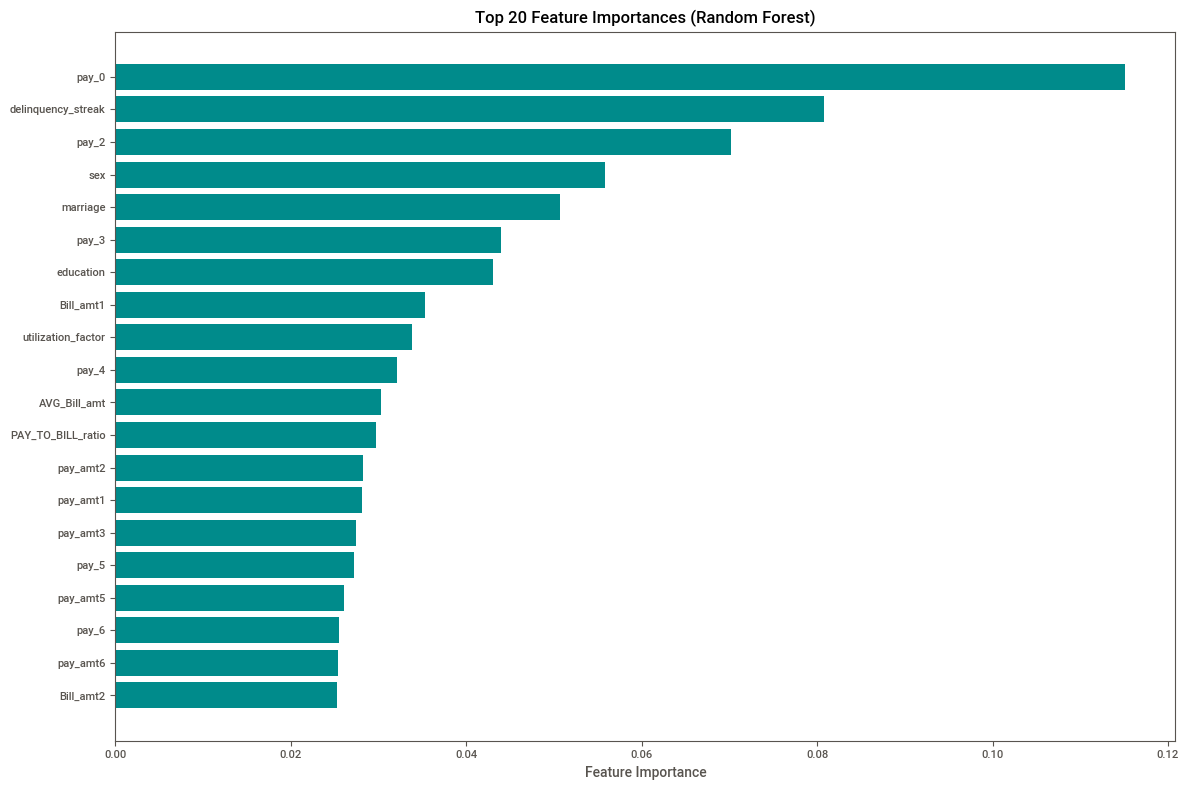

Top 10 Features:
                Feature  Importance
5                pay_0    0.115072
26  delinquency_streak    0.080756
6                pay_2    0.070185
1                  sex    0.055790
0             marriage    0.050687
7                pay_3    0.043919
2            education    0.043032
11           Bill_amt1    0.035344
25  utilization_factor    0.033757
8                pay_4    0.032115


In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_

feature_names = X_train.columns  # or X_smote.columns
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# Plot top 20
plt.figure(figsize=(12, 8))
plt.barh(feat_imp_df['Feature'].head(20)[::-1], feat_imp_df['Importance'].head(20)[::-1], color='darkcyan')
plt.xlabel('Feature Importance')
plt.title('Top 20 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

feat_imp_df.to_csv("random_forest_feature_importance.csv", index=False)

print("Top 10 Features:\n", feat_imp_df.head(10))


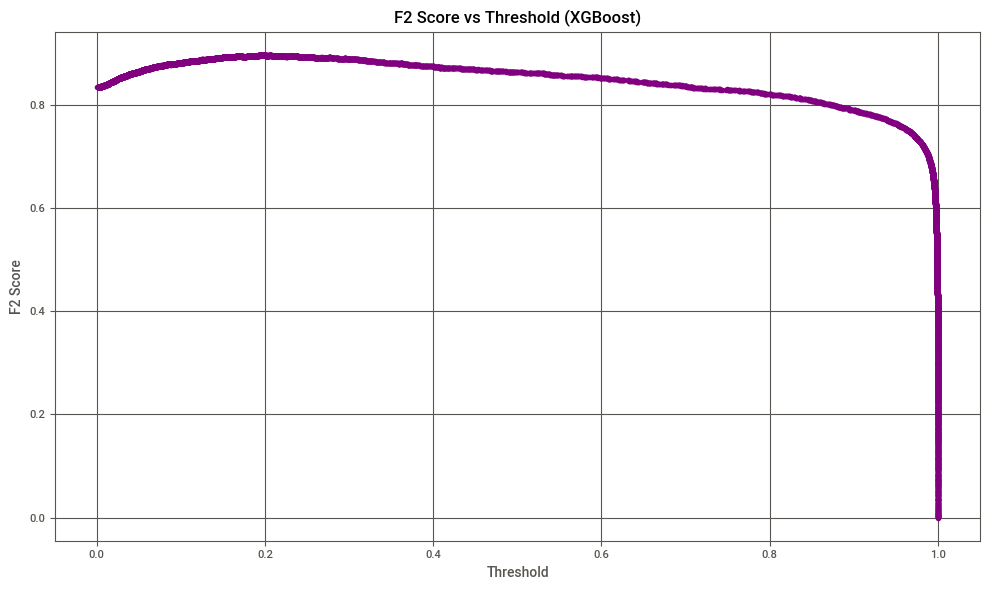

🎯 Best F2 Score: 0.8965 at Threshold: 0.1978


In [127]:
from sklearn.metrics import precision_recall_curve, fbeta_score
import matplotlib.pyplot as plt
import numpy as np

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, xgb_probs)

f2_scores = 5 * (precision * recall) / (4 * precision + recall + 1e-9)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresholds, f2_scores[:-1], marker='o', color='purple')
plt.title("F2 Score vs Threshold (XGBoost)")
plt.xlabel("Threshold")
plt.ylabel("F2 Score")
plt.grid(True)
plt.tight_layout()
plt.show()


best_idx = np.argmax(f2_scores)
print(f" Best F2 Score: {f2_scores[best_idx]:.4f} at Threshold: {thresholds[best_idx]:.4f}")


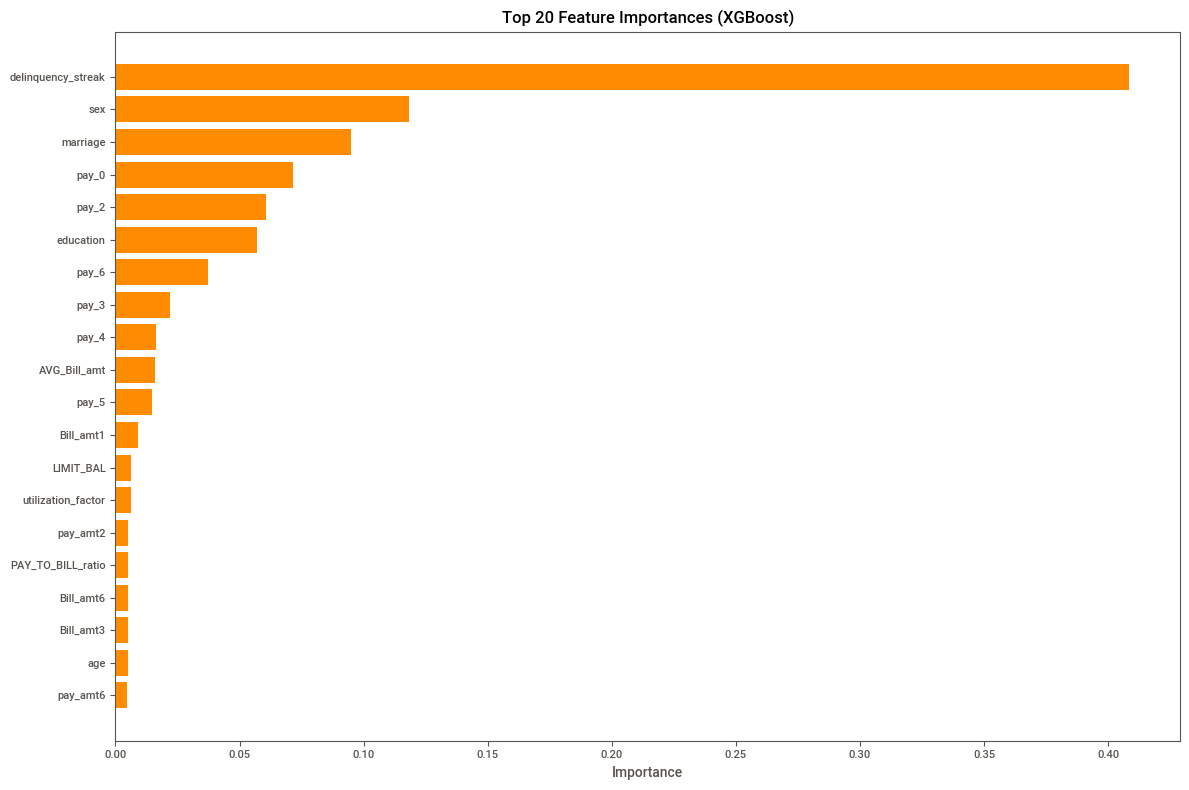

🔝 Top 10 Important Features (XGBoost):
               Feature  Importance
26  delinquency_streak    0.408574
1                  sex    0.118236
0             marriage    0.094797
5                pay_0    0.071383
6                pay_2    0.060862
2            education    0.057073
10               pay_6    0.037474
7                pay_3    0.021842
8                pay_4    0.016160
23        AVG_Bill_amt    0.016027


In [128]:
import pandas as pd
import matplotlib.pyplot as plt


xgb_importances = xgb_model.feature_importances_
feature_names = X_train.columns

xgb_feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(xgb_feat_df['Feature'].head(20)[::-1], xgb_feat_df['Importance'].head(20)[::-1], color='darkorange')
plt.title("Top 20 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

xgb_feat_df.to_csv("xgboost_feature_importance.csv", index=False)

print("Top 10 Important Features (XGBoost):")
print(xgb_feat_df.head(10))


In [123]:
import pandas as pd
import numpy as np

validate_df = pd.read_csv("validate_dataset_final.csv")

validate_df['education'] = validate_df['education'].apply(lambda x: 4 if x > 4 else x)

train_cols = ['marriage', 'sex', 'education', 'LIMIT_BAL', 'age',
              'pay_0', 'pay_2', 'pay_3', 'pay_4', 'pay_5', 'pay_6',
              'Bill_amt1', 'Bill_amt2', 'Bill_amt3', 'Bill_amt4', 'Bill_amt5', 'Bill_amt6',
              'pay_amt1', 'pay_amt2', 'pay_amt3', 'pay_amt4', 'pay_amt5', 'pay_amt6']

missing = set(train_cols) - set(validate_df.columns)
if missing:
    raise ValueError(f"Missing columns in validation data: {missing}")

validate_df['AVG_Bill_amt'] = validate_df[[f'Bill_amt{i}' for i in range(1, 7)]].mean(axis=1)
validate_df['total_bill'] = validate_df[[f'Bill_amt{i}' for i in range(1, 7)]].sum(axis=1)
validate_df['total_pay'] = validate_df[[f'pay_amt{i}' for i in range(1, 7)]].sum(axis=1)
validate_df['PAY_TO_BILL_ratio'] = validate_df['total_pay'] / (validate_df['total_bill'] + 1)
validate_df['utilization_factor'] = validate_df['AVG_Bill_amt'] / (validate_df['LIMIT_BAL'] + 1)

def max_consecutive_lates(row):
    streak = max_streak = 0
    for val in row:
        if val > 0:
            streak += 1
            max_streak = max(max_streak, streak)
        else:
            streak = 0
    return max_streak

pay_status_cols = [f'pay_{i}' for i in [0, 2, 3, 4, 5, 6]]
validate_df['delinquency_streak'] = validate_df[pay_status_cols].apply(max_consecutive_lates, axis=1)

final_features = train_cols + ['AVG_Bill_amt', 'PAY_TO_BILL_ratio', 'utilization_factor', 'delinquency_streak']
validate_df_final = validate_df[final_features].copy()

from sklearn.impute import SimpleImputer
imputer_val = SimpleImputer(strategy='mean')
validate_imputed = pd.DataFrame(imputer_val.fit_transform(validate_df_final), columns=validate_df_final.columns)


val_probs = rf_model.predict_proba(validate_imputed)[:, 1]
best_threshold = 0.5
val_preds = (val_probs >= best_threshold).astype(int)


submission = pd.DataFrame({
    'Customer_ID': validate_df['Customer_ID'],
    'next_month_default': val_preds
})

submission.to_csv("submission_final_rf.csv", index=False)
print(" Submission saved to submission_final_rf.csv")


 Submission saved to submission_final_rf.csv
